# Проект: Статистический анализ данных (для сервиса аренды самокатов)

**Описание проекта**

Вы аналитик популярного сервиса аренды самокатов GoFast. Вам передали данные о некоторых пользователях из нескольких городов, а также об их поездках. Проанализируйте данные и проверьте некоторые гипотезы, которые могут помочь бизнесу вырасти.

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться: *Описание сокращено в рамках этики работы с предоставлемыми данными* без подписки и с подпиской.Тарифы отличаются наличием и отсутсвием абонплаты, стоимостью одной минуты поездки, а также стоимостью старта.
        
**Цели проекта**

- Изучить информацию о пользователях и их поездках, в том числе в зависимости от наличия и отсутствия подписки.
- Проверить предложенные продакт-менеджерами гипотезы для последующего проведения акций, направленных на увеличение количества пользователей с подпиской.

**План работы**

1. Провести предобработку данных, изучив пропуски, дубликаты и аномалии, исправив их там, где это возможно и необходимо, дополнительно добавить в случае потребности новые столбцы для удобства исследования и исправив типы данных на более подходящие.
2. Провести исследовательский анализ данных, описав и визуализировав информацию о пользователях и поездках.
3. Объединить полученные данные о пользователях, поездках и подписках в один датафрейм. Создать на его основе два новых датафрейма с информацией о пользователях с подпиской и пользователях без подписки. Визуализировать информацию о расстоянии и времени поездок для пользователей обеих категорий.
4. Подсчитать помесячную выручку для каждого из пользователей каждой из категорий на основе созданных для этих целей агрегированных датафреймов.
5. Проверить выданные для этих целей гипотезы.
6. Решить дополнительные задачи от технической команды сервиса и отдела маркетинга.
7. Оформить выводы и подготовить рекомендации.

**Описание данных**

*Описание сокращено в рамках этики работы с предоставлемыми данными*

В основных данных есть информация о пользователях, их поездках и подписках.

Пользователи — `'users_go.csv'`

Поездки — `'rides_go.csv'`

Подписки — `'subscriptions_go.csv'`

Предварительно подключим необходимые в дальнейшем библиотеки.

In [ ]:
import pandas as pd
import seaborn as sns # для некоторых графиков
import matplotlib.pyplot as plt

import math
from math import factorial # для задач
from math import sqrt # для задач с апроксимацией

import numpy as np
from numpy import random # для графика в задаче

from scipy import stats as st # для ttest-а гипотез
from scipy.stats import norm # для задач
from scipy.stats import binom # для задач

#from IPython.display import display
from pandas.api.types import CategoricalDtype # для задавания порядка категорий

#pd.options.display.max_columns = 30 # настройки отображения таблиц датафреймов
#pd.options.display.max_rows = 8000

#### Загрузка данных

Мы имеем три датасета, информация из которых потребуется нам для дальнейшего исследования.

Прежде чем приступить к работе откроем эти датасеты и посмотрим на их содержимое.

In [ ]:
#ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
try:
    users_go = pd.read_csv('/datasets/users_go.csv')
except:
    users_go = pd.read_csv('https://адрес_удален/datasets/users_go.csv')

In [ ]:
users_go.head(20)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


In [ ]:
users_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


Датасет `'users_go'` содержит в себе информацию, касающуюся личных данных пользователей (id, имя, возраст, город пользователя, а также наличие или отсутствие подписки).

Возможно, некоторые пользователи получили несколько id (например, id 7 и 20 принадлежат некому подписчику Игорю 23х лет из Омска). Но не исключено также, что это разные люди, ведь ни их фамилии, ни электронная почта либо телефон (или иные дополнительные данные, позволяющие более точно идентифицировать пользователей как одного человека, либо как разных) нам неизвестны.

Всего датасет содержит в себе 1565 строк, в которых не имеется пропусков. Предположительно уникальных пользователей, попавших в данную выборку, у нас также выходит 1565.

Имена столбцов соответствуют правилам хорошего тона и содержимому, а потому не требуют переименования. Типы данных в имеющихся столбцах предварительно соответствуют содержимому, однако наличие и отсутствие подписки теоретически можно будет далее перевести в тип данных 'category'.

In [ ]:
try:
    rides_go = pd.read_csv('/datasets/rides_go.csv')
except:
    rides_go = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')

In [ ]:
rides_go.head(20)

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22


In [ ]:
rides_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


Датасет `'rides_go'` содержит в себе информацию, касающуюся поездок указанных через id пользователей: расстоянии, затраченном на поездку времени и дату, когда она совершалась.

Так как датасеты `'users_go'` и `'rides_go'` оба имеют столбец `'user_id'`, то объединять между собой эти два датасета необходимо будет по нему.

Всего датасет содержит в себе 18068 строк, в которых не имеется пропусков. Предположительно уникальных поездок, попавших в данную выборку, у нас также выходит 18068.

Имена столбцов соответствуют правилам хорошего тона и содержимому, а потому не требуют переименования. Типы данных в имеющихся столбцах предварительно соответствуют содержимому, за исключением столбца `'date'`, который в дальнейшем требуется перевести в тип данных 'datetime'.

In [ ]:
try:
    subscriptions_go = pd.read_csv('/datasets/subscriptions_go.csv')
except:
    subscriptions_go = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

In [ ]:
subscriptions_go.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [ ]:
subscriptions_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


Датасет `'subscriptions_go'` содержит в себе информацию, касающуюся тарифов за услуги аренды самокатов в зависимости от наличия или отсутствия у пользователя подписки.

Столбец с именем `'subscription_type'` имеется как в данном датасете, так и в датасете `'users_go'`, с которым для удобства дальнейших рассчетов можно объединить текущий датасет.

Имена столбцов соответствуют правилам хорошего тона и содержимому, а потому не требуют переименования. Тип данных столбца `'subscription_type'` также лучше перевести в тип данных 'category' для возможности объединения.

***Вывод***

На анализ получены три датасета, содержащие информацию о пользователях сервиса аренды самокатов (`'users_go'`), их поездках (`'rides_go'`) и тарифах в зависимости от наличия или отсутствия у пользователя подписки (`'subscription_type'`). В дальнейшем исследовании для удобства работы потребуется объединение трех датасетов в один.

Имена столбцов соответствуют правилам хорошего тона и содержимому, а потому не требуют переименования. Типы данных за редким исключением также соответствуют.

#### Предобработка данных

Прежде чем объединять три датасета в один, лучше предварительно изучить их по-отдельности, для облегчения процесса компьютеру и исследователю, а также произвести иные подготовительные мероприятия.

##### Изменение типов данных

Для начала исправим типы данных у некоторых из столбцов наших датасетов, а именно:

- `'date'` из object (образец формата представления даты 2021-03-15) в datetime у `'rides_go'`;
- `'subscription_type'` из object в category у `'subscriptions_go'`и`'users_go'`.

In [ ]:
subscriptions_go['subscription_type'].unique() # уточняем уникальные значения

array(['free', 'ultra'], dtype=object)

In [ ]:
subscriptions_go['subscription_type'] = subscriptions_go['subscription_type'].astype('category') # преобразовываем

In [ ]:
subscriptions_go['subscription_type'].dtypes # проверка результата

CategoricalDtype(categories=['free', 'ultra'], ordered=False)

In [ ]:
users_go['subscription_type'].unique() # уточняем уникальные значения

array(['ultra', 'free'], dtype=object)

In [ ]:
users_go['subscription_type'] = users_go['subscription_type'].astype('category') # преобразовываем

In [ ]:
users_go['subscription_type'].dtypes # проверка результата

CategoricalDtype(categories=['free', 'ultra'], ordered=False)

In [ ]:
rides_go['date'] = pd.to_datetime(rides_go['date'], format = '%Y-%m-%dT%H:%M:%S') # преобразовываем

In [ ]:
rides_go.info() # проверка 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


In [ ]:
rides_go.head() # проверка 2

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


***Вывод***

Преобразование типов данных прошло успешно.

##### Создание новых столбцов

Полученные на анализ датасеты достаточно подробные для того, чтобы производить необходимый анализ, но при этом лаконичные (не содержат "лишней" для текущего анализа информации, вроде марок самокатов или координат стоянок). Но все равно что-то придется доработать.

Мы имеем данные с конкретными датами поездок, а подписка оплачивается за месяц. Значит и финансовую (и иную) информацию нам тоже удобнее считать также помесячно. Потому введем в датасет `'rides_go'` новый столбец с указанием месяца, когда совершалась поездка.

Но сначала проверим, сколько лет у нас представлено в датасете, чтобы ошибочно не считать одинаковые месяца в разных годах как один.

In [ ]:
rides_go['date'].dt.year.unique()

array([2021])

Все имеющиеся данные представлены за один (2021) год. А значит для подсчетов нам хватит лишь нового столбца с месяцем (а полную дату в будущем можно будет при необходимости удалить).

Создадим его.

In [ ]:
rides_go['month'] = rides_go['date'].dt.month

In [ ]:
rides_go.head() # проверка

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Так же с учетом того, что пользователи платят не посекундно, а поминутно, для финансовых рассчетов нам лучше добавить столбец с округленными вверх временами поездок.

In [ ]:
#rides_go['duration_ceil'] = np.ceil(rides_go['duration']).astype(int)

In [ ]:
rides_go.insert(3, 'duration_ceil', np.ceil(rides_go['duration']).astype(int))

In [ ]:
rides_go.head() # проверка

,user_id,distance,duration,duration_ceil,date,month
0,1,4409.919140,25.599769,26,2021-01-01,1
1,1,2617.592153,15.816871,16,2021-01-18,1
2,1,754.159807,6.232113,7,2021-04-20,4
3,1,2694.783254,18.511000,19,2021-08-11,8
4,1,4028.687306,26.265803,27,2021-08-28,8


***Вывод***

Данные по поездкам в датасете представлены за один 2021 год.

Для удобства подсчетов в датасете `'rides_go'` созданы новые столбцы `'month'` и `'duration_ceil'`.

##### Работа с пропусками и дубликатами

Как мы видели ранее, явных пропусков в имеющихся датасетах не было. Попробуем обнаружить неявные и дубликаты.

Начнем с информации о пользователях и явных дубликатах среди них.

In [ ]:
users_go.duplicated().sum()

31

Некоторые пользователи оказались учтены несколько раз. Прежде чем удалять, посмотрим на повторяющиеся id, для того, чтобы попробовать обратить внимание на тенденции образования дубликатов.

In [ ]:
users_go['user_id'].value_counts().head(32)

209     2
807     2
611     2
43      2
737     2
47      2
1198    2
829     2
924     2
153     2
635     2
72      2
909     2
908     2
136     2
1045    2
1237    2
127     2
659     2
307     2
1245    2
121     2
666     2
108     2
297     2
809     2
293     2
16      2
422     2
403     2
204     2
1035    1
Name: user_id, dtype: int64

Максимальное количество повторов для строки - два.

Задвоившихся пользователей выходит тех же 31. Если бы их было больше, то можно было бы предположить, что оставшиеся на самом деле иные пользователи, просто id у них указаны ошибочно, либо в разные месяцы они то пользовались подпиской, то нет. Но так как у нас все id уникальны, то можно предположить, что все попавшие в выборку пользователи на протяжении всего года придерживались одной и той же практики оплаты, выбранной изначально. Либо одним и тем же пользователям с подпиской и без приписывают разный id (что маловероятно ввиду возникающих из-за этого сложностей изучения поведения конкретного пользователя).

Удалим явные дубликаты, а затем еще раз глянем на повторяющиеся id.

In [ ]:
users_go = users_go.drop_duplicates().reset_index(drop=True)

In [ ]:
users_go.duplicated().sum() # проверка на оставшиеся явные дубликаты

0

In [ ]:
users_go.duplicated(subset=['user_id', 'name','age', 'city']).sum() # проверка на дубли id

0

In [ ]:
users_go.duplicated(subset=['user_id']).sum()

0

На всякий случай, взглянем, есть ли возможные тезки среди пользователей?

In [ ]:
users_go.duplicated(subset=['name','age', 'city']).sum()

53

53 пользователя совпадают по своим персональным данным. Возможно, это одни и те же люди, заведшие себе несколько аккаунтов, а может быть действительно тезки. Так как правду установить сложно, количество таких строк относительно датасета небольшое, а в приоритете у нас все-таки id, то будем считать данных пользователей разными людьми.

In [ ]:
users_go.info() # проверка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   user_id            1534 non-null   int64   
 1   name               1534 non-null   object  
 2   age                1534 non-null   int64   
 3   city               1534 non-null   object  
 4   subscription_type  1534 non-null   category
dtypes: category(1), int64(2), object(2)
memory usage: 49.7+ KB


После удаления дубликатов строк в датасете `'users_go'` стало меньше.

Взглянем на уникальные имена пользователей и названия городов, чтобы исключить возможных скрытых дубликатов и пропусков.

In [ ]:
len(users_go['name'].unique()) # считаем имена

194

In [ ]:
sorted(users_go['name'].unique()) # смотрим на имена

['Агата',
 'Аделина',
 'Адель',
 'Айдар',
 'Александр',
 'Александра',
 'Алексей',
 'Алина',
 'Алиса',
 'Алия',
 'Алла',
 'Альберт',
 'Альбина',
 'Алёна',
 'Амалия',
 'Амина',
 'Амир',
 'Анастасия',
 'Анатолий',
 'Ангелина',
 'Андрей',
 'Анжелика',
 'Анна',
 'Антон',
 'Антонина',
 'Ариана',
 'Арина',
 'Арсен',
 'Арсений',
 'Артемий',
 'Артур',
 'Артём',
 'Богдан',
 'Борис',
 'Вадим',
 'Валентина',
 'Валерий',
 'Валерия',
 'Варвара',
 'Василий',
 'Василина',
 'Василиса',
 'Вера',
 'Вероника',
 'Виктор',
 'Виктория',
 'Виолетта',
 'Виталий',
 'Виталина',
 'Влад',
 'Влада',
 'Владимир',
 'Владислав',
 'Владислава',
 'Всеволод',
 'Вячеслав',
 'Галина',
 'Георгий',
 'Герман',
 'Глеб',
 'Гордей',
 'Григорий',
 'Давид',
 'Дамир',
 'Даниил',
 'Данил',
 'Данила',
 'Даниэль',
 'Дарина',
 'Дарья',
 'Демид',
 'Денис',
 'Диана',
 'Дмитрий',
 'Ева',
 'Евгений',
 'Евгения',
 'Егор',
 'Екатерина',
 'Елена',
 'Елизавета',
 'Елисей',
 'Есения',
 'Жанна',
 'Зарина',
 'Захар',
 'Злата',
 'Иван',
 'Игнат',

In [ ]:
users_go['name'].value_counts().head(5) # смотрим самые популярные для "портрета пользователя"

Анна         22
Мария        22
Александр    17
Дмитрий      17
Никита       16
Name: name, dtype: int64

194 уникальных имени. Кажется немного для более чем полторы тысяч id. Но с учетом того, что "уникальность наименования" конкретному человеку дает не только имя, но и фамилия (которые более разнообразны, чем "устоявшиеся" (то есть популярные и относительно популярные имена)) и их сочетания - это неплохой результат, а значит отличать одного пользователя от другого, имея о нем крайне скудную персональную иформацию будет легче.

Самые популярные имена - Мария и Анна среди пользователей женского пола, Александр и Дмитрий - среди мужчин.

Даниил, Данил, Данила и Даниэль похожи по написанию и могут быть вариантом одного и того же исходного имени, однако в данном случае, с учетом разнообразия человеских имен, с большой долей вероятности это разные пользователи.

Чтобы в этом убедиться, выведем их данные на экран.

In [ ]:
users_go.loc[(users_go['name'] == 'Даниил')|(users_go['name'] =='Данил')\
         |(users_go['name'] =='Даниэль')|(users_go['name'] =='Данила')].sort_values(by='city')

,user_id,name,age,city,subscription_type
40,41,Данила,21,Екатеринбург,ultra
106,107,Данила,26,Екатеринбург,ultra
940,941,Данила,28,Екатеринбург,free
147,148,Данил,18,Екатеринбург,ultra
628,629,Данил,19,Екатеринбург,ultra
1344,1345,Даниэль,26,Екатеринбург,free
1444,1445,Даниил,25,Краснодар,free
176,177,Данил,25,Краснодар,ultra
849,850,Данила,32,Краснодар,free
684,685,Даниил,25,Краснодар,ultra


В Краснодаре у нас присутствуют целых три пользователя с указанными именами 25 лет - интересное совпадение. Причем два из них имеют одинаковый вариант и отличаются только подпиской.

Однако для города-миллионника (люди-тезки в базах данных) это вполне обычное явление.

Посмотрим, сколько у нас городов и нет ли ошибок написания у них.

In [ ]:
len(users_go['city'].unique()) # считаем города

8

In [ ]:
sorted(users_go['city'].unique()) # смотрим на города

['Екатеринбург',
 'Краснодар',
 'Москва',
 'Омск',
 'Пятигорск',
 'Ростов-на-Дону',
 'Сочи',
 'Тюмень']

Имеем 8 городов в исследовании. Скрытых пропусков и дубликатов среди них не обнаружено.

Взглянем на возраст пользователей.

In [ ]:
users_go['age'].sort_values().unique()

array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 43])

В выборке представлены пользователи от 12 до 43 лет. Это выглядит необычно, так как у многих сервисов аренда разрешена минимум с 14, 16, а то и 18 лет (также могут быть ограничения по возрасту согласно местному законодательству). Возможно, у заказчика свои внутренние правила, либо произошел недосмотр, и к управлению были допущены не имеющие на это право лица, либо ошибка в указании возраста (не 12, а 22).

Искать пропуски и дубликаты в датасете с описанием тарифов `'subscriptions_go'` нет необходимости, так как их отсутствие мы могли увидеть ранее, поэтому переходим к датасету `'rides_go'` с информацией о поездках.

Начнем с явных дубликатов.

In [ ]:
rides_go.duplicated().sum()

0

Как и следовало ожидать, явных дубликатов не обнаружено. Можем глянуть, катались ли пользователи вместе?

In [ ]:
rides_go.duplicated(subset=['distance','duration', 'date']).sum()

0

Явных признаков того, что несколько человек могли кататься вместе рядом по одному и тому же маршруту (например, несколько друзей или пара на свидании) не обнаружено. Но это может быть обусловлено особенностями геолоцирования и точностью измерений.

Также можем глянуть, использовал ли один и тот же пользователь самокат в один и тот же день несколько раз.

In [ ]:
rides_go.duplicated(subset=['user_id', 'date']).sum() # считаем количество

292

In [ ]:
rides_go.duplicated(subset=['user_id', 'date']).sum()/len(rides_go['user_id'])*100 # считаем процент

1.6161168917423068

Лишь 1.6% поездок совершались одними и теми же пользователями несколько раз в день. Немного, но если посмотреть по месяцам?

In [ ]:
rides_go.duplicated(subset=['user_id', 'month']).sum()/len(rides_go['user_id'])*100

37.28691609475315

37,3% поездок совершалась одними и теми же пользователями в течении месяца. Уже неплохо, и наглядно показывает наличие постоянных активных клиентов.

In [ ]:
len(rides_go['user_id'].unique()) # считаем уникальных пользователей

1534

Количество уникальных id у датасета `'rides_go'`совпадает с таковым у датасета `'users_go'`, что предварительно может утверждать, что у нас не образуется пропусков после их объединения (но всегда есть шанс, что на самом деле часть id в указанных датасетах не совпадает, поэтому в правдивости предположения мы сможем убедиться позже).

***Выводы***

Типы данных в некоторых столбцах (`'date'` у `'rides_go'` и `'subscription_type'` у `'subscriptions_go'`и`'users_go'`) были преобразованы в более подходящий (datetime и category соответственно).

Для удобства подсчетов в датасете `'rides_go'` созданы новые столбцы `'month'` и `'duration_ceil'`

В датасете `'users_go'` обнаружен и удален 31 явный дубликат. Также в нем мы имеем 194 уникальных имени и 8 городов в исследовании. Скрытых пропусков и дубликатов среди них не обнаружено. Однако обнаружен слишком малый (12, 13 лет) возраст арендаторов, что может быть политикой (разрешением) компании-заказчика, ошибкой внесении данных, либо недосмотром, в результате которого доступ к аренде и управлению самокатом получили лица, не имеющие на то право.

В датасете `'rides_go'` скрытых пропусков, явных и неявных дубликатов не обнаружено. Также мы имеем 1534 уникальных id пользователей, что совпадает с количеством таковых у датасета `'users_go'`, что может дать предположение о том, что у нас может не появиться строк с пропусками после объединение данных датасетов.

37,3% поездок являются повторными, то есть совершаются одними и теми же пользователями в течении месяца.
Самые популярные имена пользователей - Мария и Анна среди пользователей женского пола, Александр и Дмитрий - среди мужчин.

#### Исследовательский анализ данных

После подготовки и очистки данных можно приступить непосредственно к исследованию и визуализации.

##### Частота встречаемости городов

Мы уже установили, что в нашу выборку попали 8 городов. Так как подобный сервис дорогостоящ для владельцев (закупка и обслуживание оборудования, лицензия и прочие расходы), чтобы держать и развивать его в местах с малым количеством пользователей, это могут быть все города, в которых в принципе работает сервис заказчика (если бы он работал в еще каких-то городах, то при случайном подборе выборке велика их вероятность попадания в нее даже при малом количестве пользователей хотя в единичном экземпляре). Либо компания-заказчик сама предварительно отобрала данные по наиболее наглядным/интересным ей городам, (в том числе чтобы чтобы нам не пришлось дополнительно исключать малые города с небольшим числом пользователей). Но, если исходить из описания проекта - наш вариант тот, где компания сама решила, какие города ей интересны для изучения.

В основном это города-миллионники, но есть несколько просто крупных городов.  Самый маленький город в выборке - Пятигорск.

Посмотрим частоту встречаемости городов, что может подсказать нам, где пользователей больше. Логично предположить, что лидером окажется Москва как наиболее крупный город. Но что нам скажут наши данные?

In [ ]:
users_go['city'].value_counts() # считаем

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

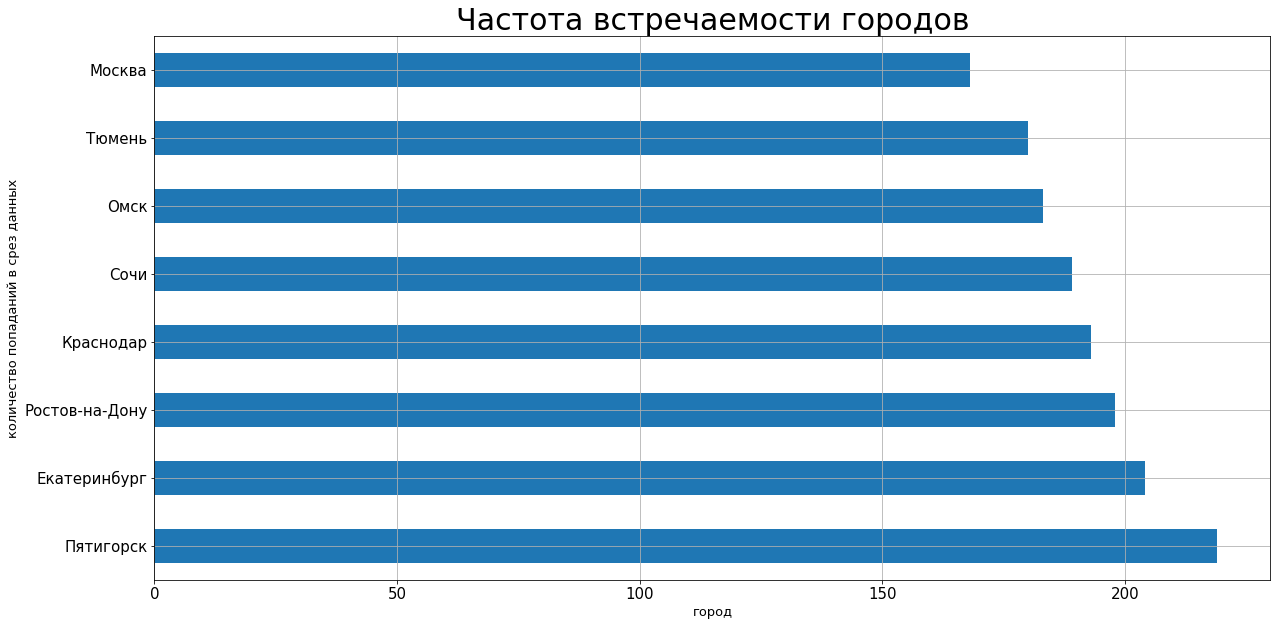

In [ ]:
users_go['city'].value_counts().plot(kind = 'barh', grid = True, figsize = (20,10), fontsize=15) # визуализируем

plt.title('Частота встречаемости городов', fontsize=30)
plt.xlabel('город', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

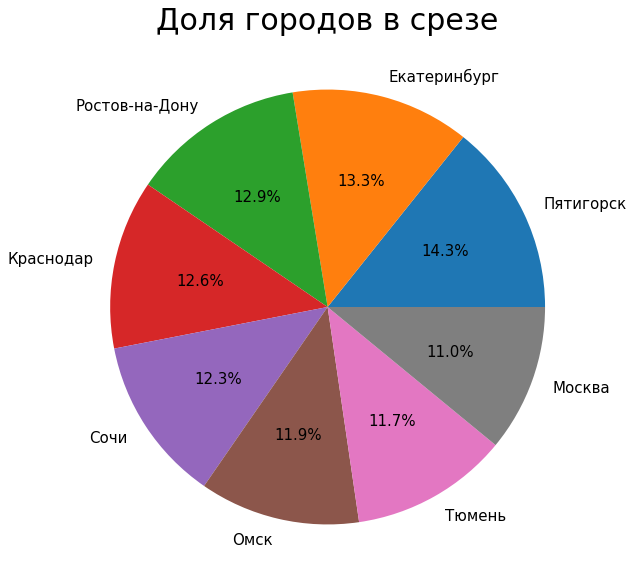

In [ ]:
users_go['city'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%') # визуализируем 2

plt.title('Доля городов в срезе', fontsize=30)
#plt.axis('equal')
#plt.xlabel('город', fontsize=13)
plt.ylabel('', fontsize=13)

plt.show()

Самым частым городом (219 попаданий, что составляет 14.3%) оказался самый маленький из городов - Пятигорск. Москва же, несмотря на свое огромное население, напротив заняла последнее место (168 попаданий, 11%). Возможно, это связано с высокой конкуренцией подобных сервисов в Москве и низкой - Пятигорске (где компания-заказчик может оказаться и вовсе монополистом) и иных, попавших в наше исследование, городах.

##### Соотношение пользователей с подпиской и без

У нас есть два варианта пользования пользования сервиса: с подпиской и без. Посмотрим, как соотносятся категория подписчиков и  не-подписчиков.

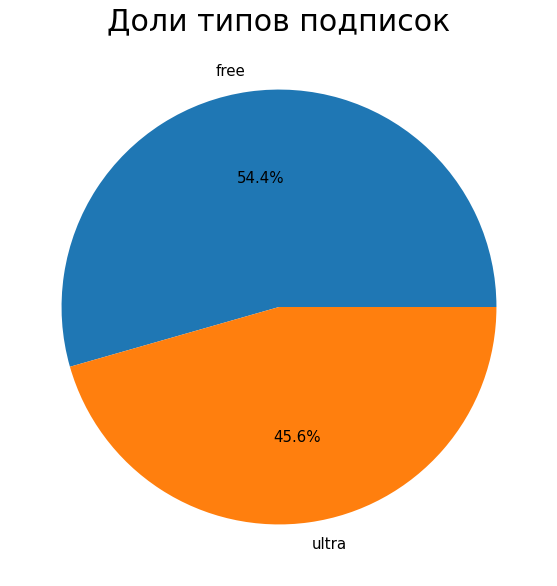

In [ ]:
users_go['subscription_type'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%') # визуализируем 2

plt.title('Доли типов подписок', fontsize=30)
#plt.axis('equal')
#plt.xlabel('город', fontsize=13)
plt.ylabel('', fontsize=13)

plt.show()

Существенного перевеса ни у одного из вариантов нет, однако большинство (54.4%) пользователей предпочитают не использовать подписку. Это может быть связано с тем, что им редко требуется самокат для поезки куда-либо, либо условия подписки в данном сервисе не устраивают (ведь нельзя исключить, что пользователь, не являющийся подписчиков в нашем сервисе, не является подписчиков в ином аналогичном сервисе конкурента и использует самокат заказчика тогда, когда нет альтернативы).

Попробуем взглянуть на поведение пользователей в разрезе городов.

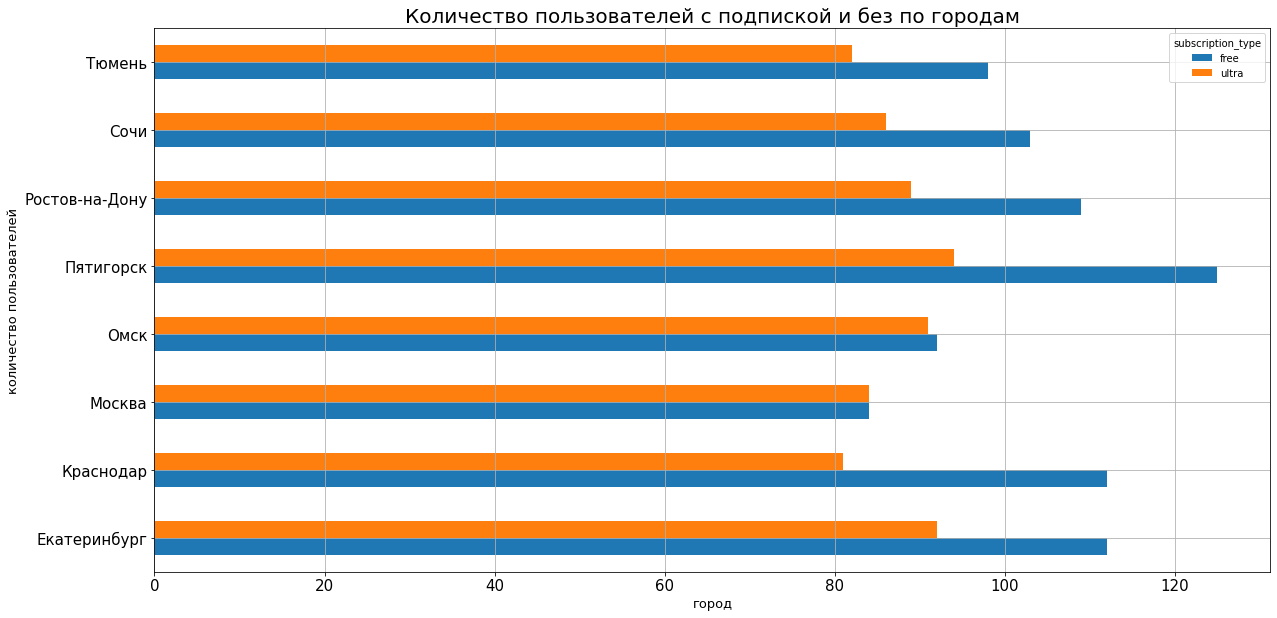

In [ ]:
users_go.pivot_table(index='city', columns = 'subscription_type',  values='user_id', aggfunc='count')\
.plot(kind = 'barh', grid = True, figsize = (20,10), fontsize=15)

plt.title('Количество пользователей с подпиской и без по городам', fontsize=20)
plt.xlabel('город', fontsize=13)
plt.ylabel('количество пользователей', fontsize=13)

plt.show()

Доля пользователей без подписки гораздо выше везде, кроме Москвы (где их доли равны) и Омска (где доля пользователей без подписки лишь ненамного выше доли пользователей с подпиской).

##### Возраст пользователей

Мы уже видели возможные возраста пользователей сервиса (в том числе и подозрительно малые для права пользования сервисом). Теперь взглянем на распределение пользователей по возрастам.

Так как у нас достаточно много вариантов, и все из них числа, для начала можно взглянуть на гистограмму и статистическое описание данных.

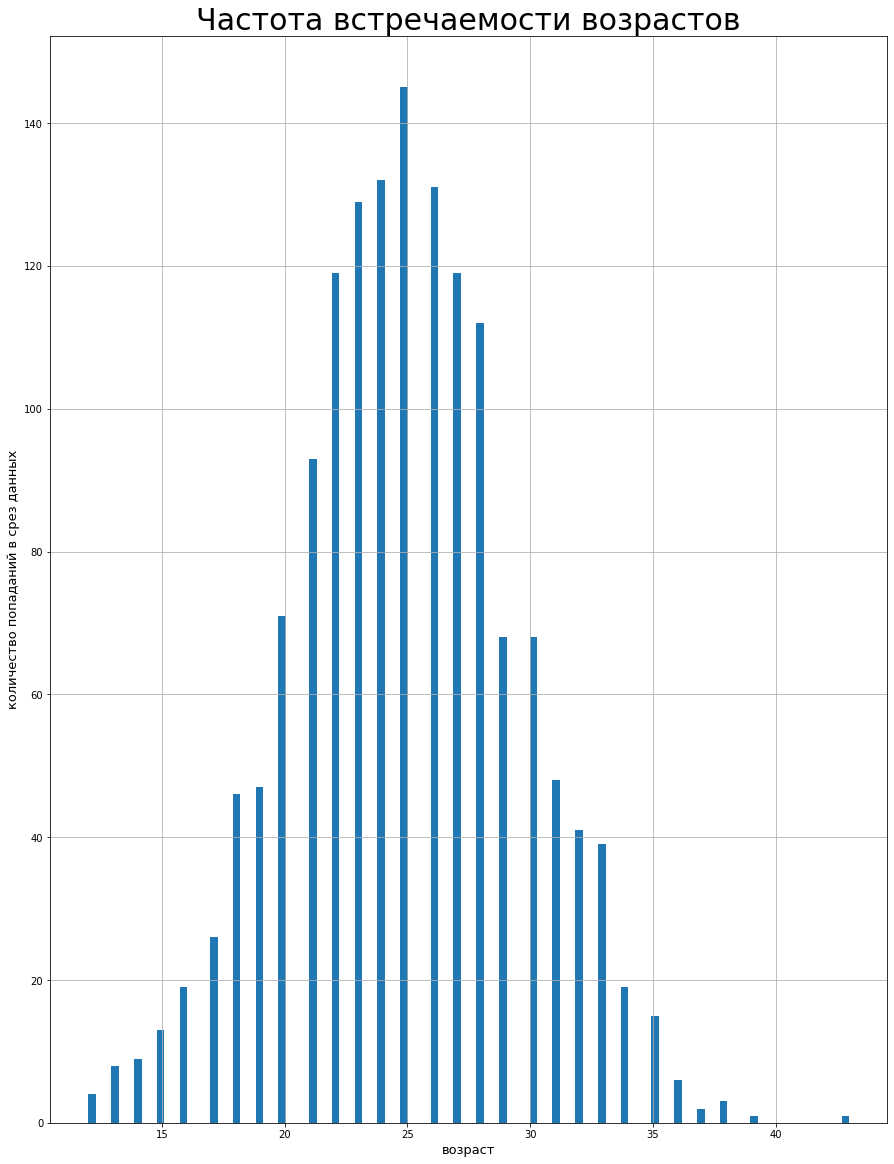

In [ ]:
users_go['age'].hist(figsize=(15,20), bins = 100, grid = True)

plt.title('Частота встречаемости возрастов', fontsize=30)
plt.xlabel('возраст', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

<AxesSubplot:>

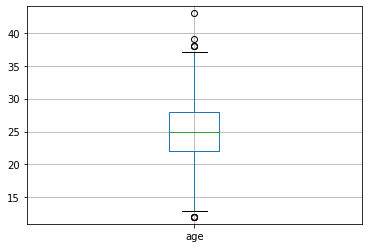

In [ ]:
plt.ylim(11,44)
users_go.boxplot(column=['age'])

In [ ]:
users_go['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

Распределение возрастов близко к нормальному.

Как мы видели ранее, минимальный возраст составил 12 лет, максимальный - 43, но это единичные случаи, которые можно считать аномалией. Однако в рамках данного исследования мы не будем их исключать.

"Нормальным" возрастом пользователя может счиаться от 13 до 37, но большинство пользователей - люди возрастом 22-28 лет. Средний практически совпадает с медианным, и они составляют 25 лет. Стандартное отклонение невелико, что говорит о хорошем качестве выборки.

Можем еще также глянуть на распределение возрастов среди пользователей с подпиской и без.

Сначала взглянем на гистограммы по-отдельности, а затем совместим для наглядности.

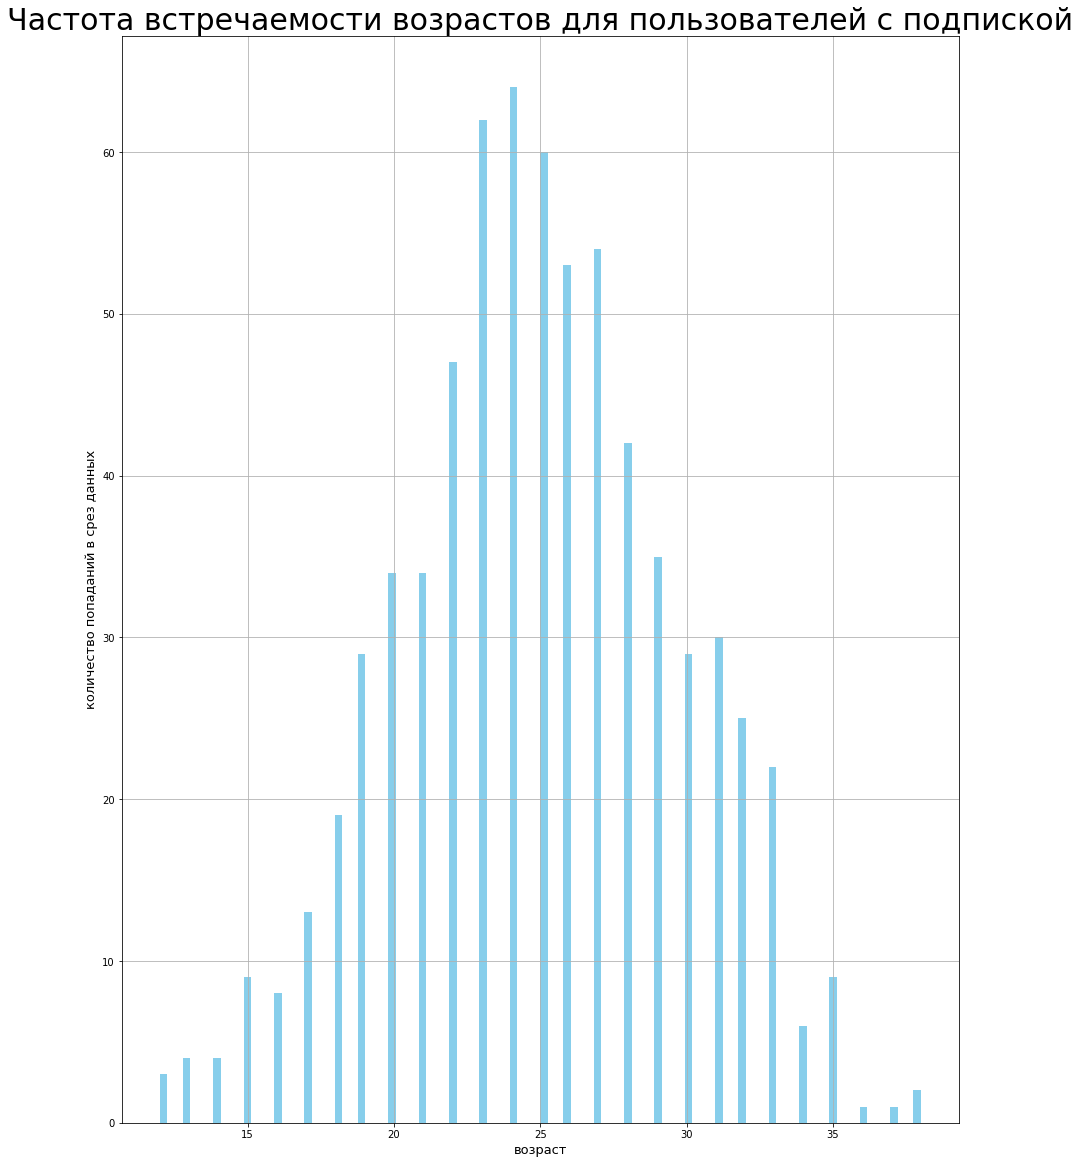

In [ ]:
users_go.query('subscription_type == "ultra"')['age'].hist(figsize=(15,20), color='skyblue', bins = 100, grid = True)

plt.title('Частота встречаемости возрастов для пользователей с подпиской', fontsize=30)
plt.xlabel('возраст', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

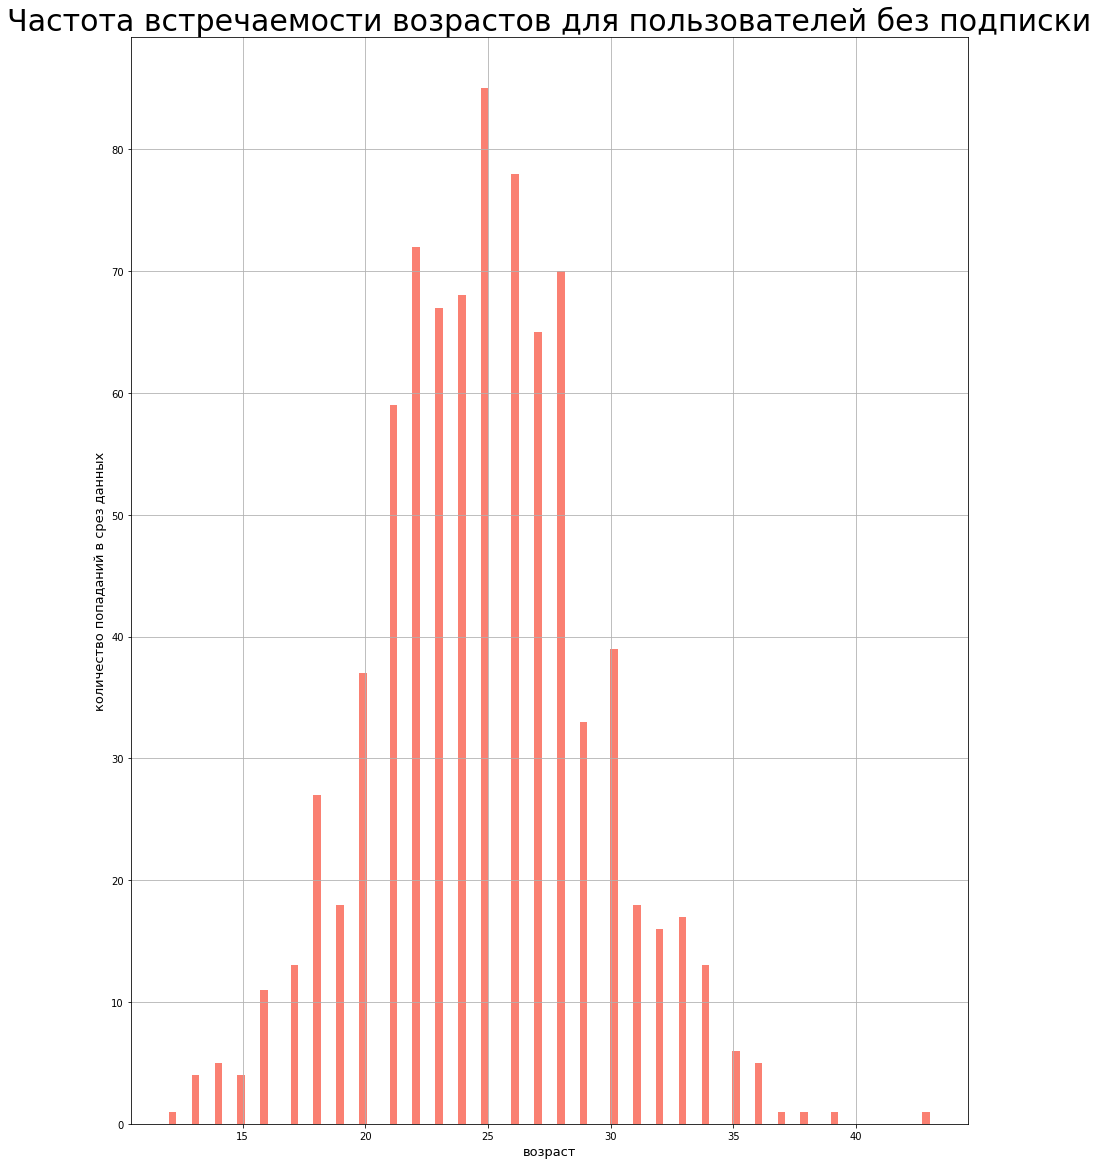

In [ ]:
users_go.query('subscription_type == "free"')['age'].hist(figsize=(15,20), color='salmon', bins = 100, grid = True)

plt.title('Частота встречаемости возрастов для пользователей без подписки', fontsize=30)
plt.xlabel('возраст', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

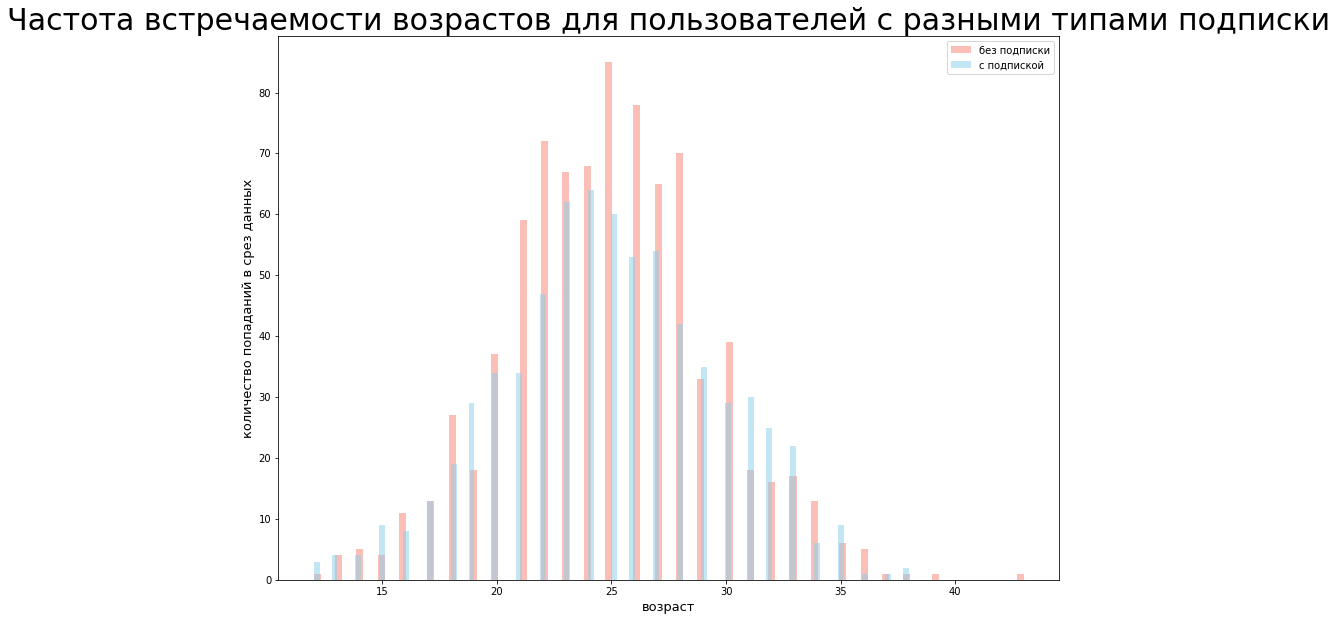

In [ ]:
plt.figure(figsize=(14, 10))  #задаём размер графика

plt.hist(users_go.query('subscription_type == "free"')['age'],\
         bins=100, color='salmon', alpha=0.5, label='без подписки')
plt.hist(users_go.query('subscription_type == "ultra"')['age'],\
         bins=100, color='skyblue', alpha=0.5, label='с подпиской')

plt.title('Частота встречаемости возрастов для пользователей с разными типами подписки', fontsize=30)
plt.xlabel('возраст', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)
plt.legend(loc='best')

plt.show()

Распределение по возрастам у пользователей с подпиской и без достаточно схожи и стремяться к нормальному.

##### Расстояние, которое пользователь преодолел за одну поездку

Мы посмотрели на персональные данные пользователей и составили предварительный "портрет" типичного пользователя. Теперь нам поведение пользователей.

Для начала изучим расстояния, которые пользователь преодолевает за одну поезку.

Начнем с гистограммы и числовых описаний.

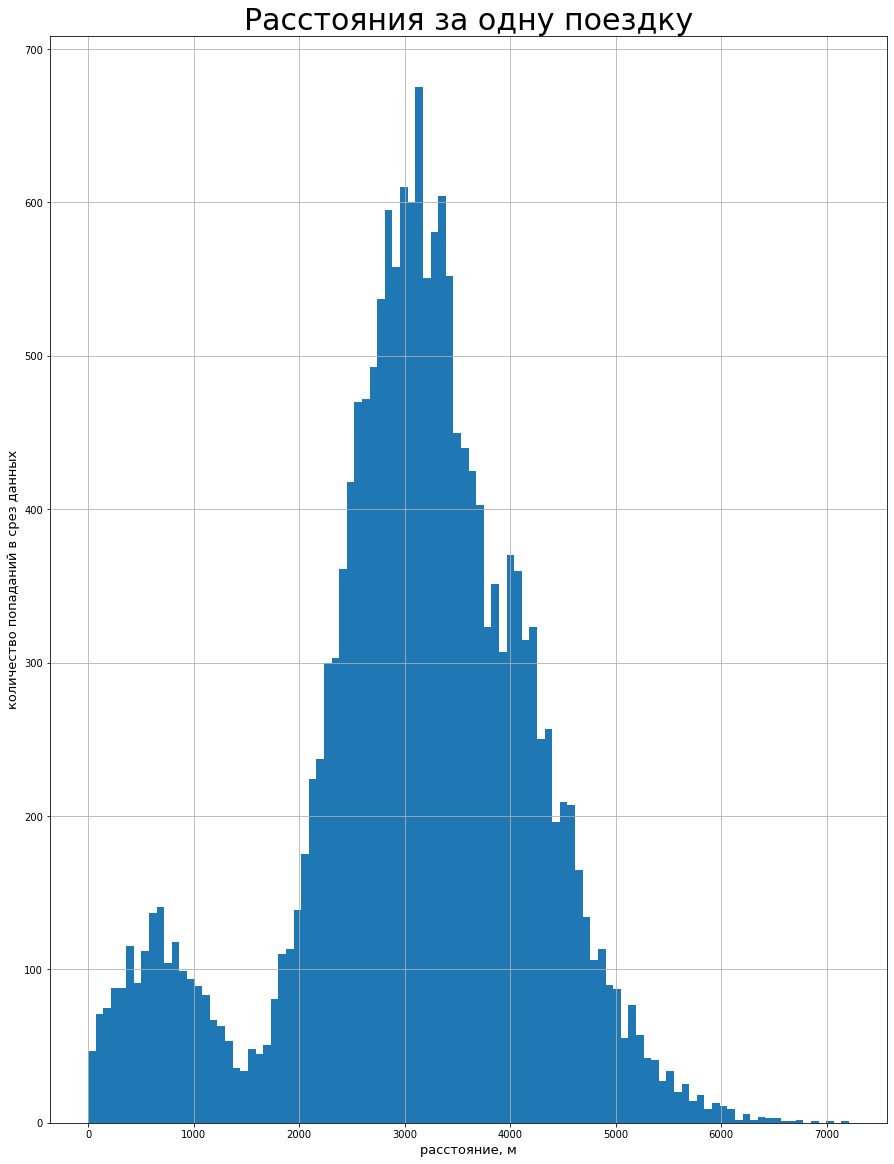

In [ ]:
rides_go['distance'].hist(figsize=(15,20), bins = 100, grid = True) # гистограмма

plt.title('Расстояния за одну поездку', fontsize=30)
plt.xlabel('расстояние, м', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

Распределение в целом похоже на нормальное, однако имеет второй пик в начале. Возможно, он вызван теми самыми пользователями из Пятигорска, ведь данный город меньше по размеру, чем остальные, поэтому и большим расстояниям взяться неоткуда, но пользователи оттуда достаточно активны.

Проверим это позже, после объединения датасетов, а пока вернемся к статистическому описанию.

<AxesSubplot:>

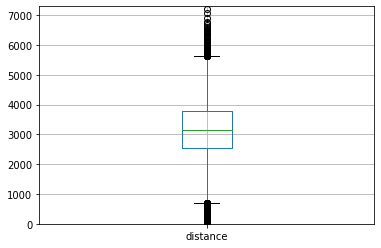

In [ ]:
plt.ylim(0,7300)
rides_go.boxplot(column=['distance'])

In [ ]:
rides_go['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

Максимальное расстояние, на которое брали самокат в аренду, составило 7.2 км, минимальное - меньше метра. Следует взглянуть на данные строки дополнительно. Однако возможно, что первый пользователь брал самокат сразу на несколько поездок в разные точки, а второй - не разобрался с сервисом либо у него закончился баланс на счету.

Стандартное отклонение большое (что может быть вызвано тем самым вторым пиком в начале). Среднее и медиана отличаются ненамного и составляют около трех километров. Нормальными можно считать поездки от 800 метров до 5.6 км, а основная масса пользователей совершают поездки от 2.5 до 3.8 км.

Чтобы понять, какие параметры можно считать "нормальными", попробуем взглянуть на "середину" выборки.

In [ ]:
rides_go[(rides_go['distance'] > 2900) & (rides_go['distance'] < 3200)]

,user_id,distance,duration,duration_ceil,date,month
6,1,3039.020292,14.927879,15,2021-10-19,10
12,2,3105.086678,24.307514,25,2021-03-15,3
13,2,3053.519401,11.543256,12,2021-03-18,3
23,3,3061.777147,12.654443,13,2021-01-31,1
26,3,2956.651632,20.671364,21,2021-04-12,4
...,...,...,...,...,...,...
18019,1531,3154.350357,18.308701,19,2021-07-04,7
18020,1531,3009.340089,19.448586,20,2021-07-18,7
18026,1531,2946.866237,14.629427,15,2021-10-22,10
18045,1533,2965.546552,23.687138,24,2021-03-23,3


Дополнительно взглянем на аномально короткие поездки.

In [ ]:
rides_go[rides_go['distance'] < 800]

,user_id,distance,duration,duration_ceil,date,month
2,1,754.159807,6.232113,7,2021-04-20,4
9,1,748.690645,15.041884,16,2021-11-22,11
47,4,724.559572,11.811399,12,2021-11-14,11
100,10,680.952663,5.150377,6,2021-02-21,2
149,15,634.891669,15.809350,16,2021-04-05,4
...,...,...,...,...,...,...
18018,1531,375.107762,5.406654,6,2021-06-27,6
18031,1532,303.787850,7.792490,8,2021-05-21,5
18037,1532,662.468186,9.528773,10,2021-11-18,11
18043,1533,310.488247,10.642389,11,2021-02-21,2


Схожие расстояния могут отличаться по времени в 1.5-3 раза, что может зависеть от скорости, с которой едет самокат, дорожных и погодных условий, реакции пользователя и его забывчивости. Но может и закрасться ошибка, например, пользаватель с id 1533 проехал на самом деле не 310 метров за 10 минут, а 3 километра.

Количество строк - более тысячи, поэтому исключать из всего исследования мы их не будем, но возможно подберем фильтры по расстоянию и времени, чтобы убрать подозрительные строки.

Теперь вглянем и на аномально длинные поездки тоже.

In [ ]:
rides_go[rides_go['distance'] > 5600]

,user_id,distance,duration,duration_ceil,date,month
6312,677,5699.769662,18.213792,19,2021-03-12,3
6549,702,5924.120648,21.156693,22,2021-11-19,11
6754,716,5835.527411,20.506582,21,2021-11-05,11
6788,719,5648.444936,19.837195,20,2021-10-13,10
6860,724,6225.520342,0.500000,1,2021-12-16,12
...,...,...,...,...,...,...
17418,1490,5830.284286,20.660569,21,2021-01-22,1
17505,1496,5722.551787,0.500000,1,2021-02-14,2
17681,1508,5600.052517,19.586316,20,2021-11-14,11
17773,1514,6039.465068,26.421033,27,2021-09-28,9


Таких строк немного, но в них видны странности: например, пользователь с id 1496 сумел преодолеть расстояние в 5,7 км за половину минуты! При том, что пользователь с id 1508 потратил на чуть меньшее расстояние почти 20 минут. Аналогичным образом "отличится" пользователь с id 724.

Подобные аномальные строки потенциально может потребоваться исключить из исследований.

##### Продолжительность поездок

Мы уже наблюдали аномалии среди расстояний за одну поездку, а также в процессе обнаружили аномалии по времени поездок.

Теперь посмотрим на продолжительность поездок внимательнее.

Снова начнем с гистограммы.

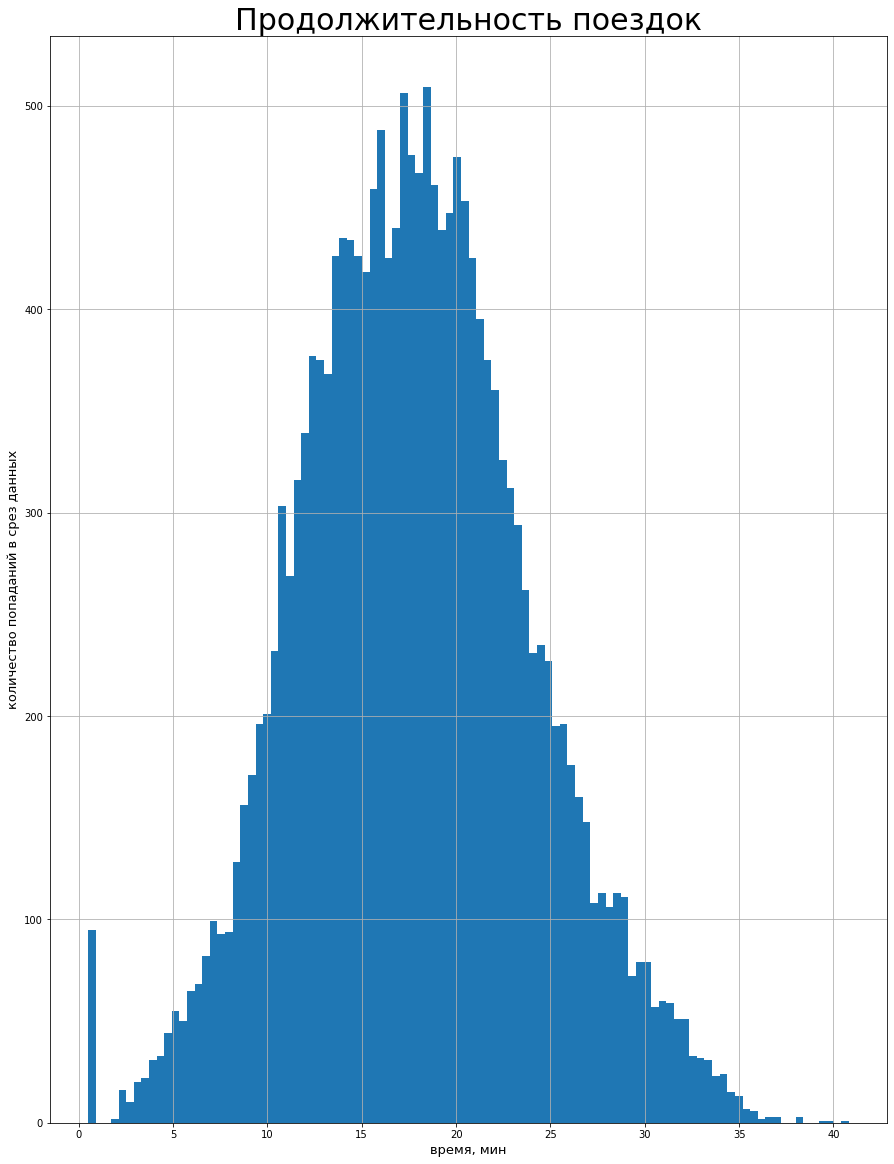

In [ ]:
rides_go['duration'].hist(figsize=(15,20), bins = 100, grid = True) # гистограмма

plt.title('Продолжительность поездок', fontsize=30)
plt.xlabel('время, мин', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

Распределение времени также похоже на нормальное, но также имеет пик в начале - видимо те самые ранее виденные полминуты.

Взглянем на них, отсортировав по расстоянию для удобства.

In [ ]:
rides_go[rides_go['duration'] == 0.5].sort_values(by='distance')

,user_id,distance,duration,duration_ceil,date,month
15132,1325,4030.308008,0.5,1,2021-12-22,12
17909,1524,4103.998874,0.5,1,2021-06-18,6
10692,1006,4106.278268,0.5,1,2021-10-31,10
9698,937,4169.066800,0.5,1,2021-12-12,12
14342,1268,4177.139336,0.5,1,2021-06-09,6
...,...,...,...,...,...,...
14574,1285,6316.574814,0.5,1,2021-09-25,9
13701,1224,6414.516026,0.5,1,2021-07-15,7
11385,1057,6601.197575,0.5,1,2021-02-07,2
17242,1477,6724.932981,0.5,1,2021-01-12,1


95 строк с расстояниями от 4 до 7.2 км, преодоленных всего за полминуты! Маловероятно, что у заказчика имеется телепорт, а значит это ошибка либо в учете расстояния, либо (что более вероятно, так как значения у всех этих строк одинаковое) - в учете времени. Возможно, это была какая-то акция (заплати за половину минуты независимо от времени поездки), либо использовались промокоды (но вероятно, тогда бы оба случая были обозначены в данных иначе, чем так).

Полчаса выглядят более вероятными для таких расстояний, однако для избегания искажений наших исследований, лучше не включать данные строки в некоторые исследования.

Попробуем построить гистограмму и статистически описать выборку, исключив время поездок в половину минуты.

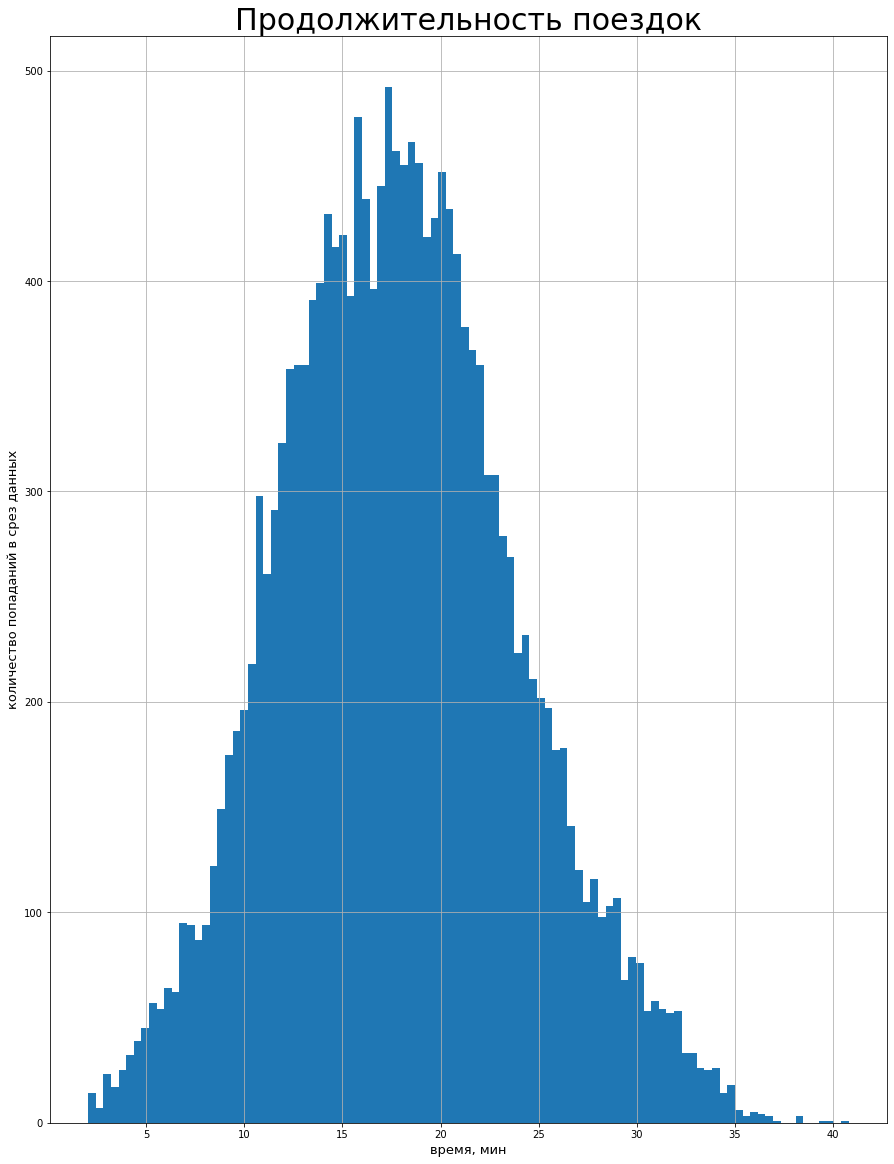

In [ ]:
rides_go.query('duration != 0.5')['duration'].hist(figsize=(15,20), bins = 100, grid = True) # гистограмма

plt.title('Продолжительность поездок', fontsize=30)
plt.xlabel('время, мин', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

Аномальный пик в начале исчез, теперь можно приступать к статистическому описанию.

<AxesSubplot:>

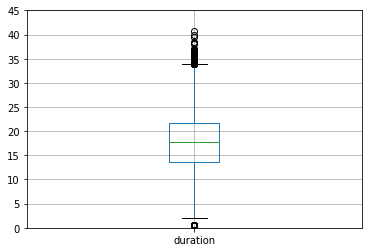

In [ ]:
plt.ylim(0,45)
rides_go.boxplot(column=['duration'])

In [ ]:
rides_go.query('duration != 0.5')['duration'].describe()

count    17973.000000
mean        17.896480
std          5.975424
min          2.035632
25%         13.670439
50%         17.714122
75%         21.747016
max         40.823963
Name: duration, dtype: float64

Максимальная поездка составила почти 41 минуту, минимальная - 2.

Стандартное отклонение велико, что говорит о неравномерности выборки, но при этом среднее и медиана отличаются мало и составляют приблизительно 18 минут.

Нормальными можно считать поездки от 3 до 34 минут, но основное большинство пользователей тратит на одну поездку 13.67 до 21.75 минут.

##### Активные месяцы

Так как у нас есть даты поездок, мы можем взглянуть отличается ли активность пользователей по месяцам. Ведь зимой может быть труднее справляться с самокатом. чем летом, да и некоторые аналогичне по услугам компании и вовсе сворачивают аренду на снежное вреям года.

Взглянем, зависит ли активность пользователей в зависимости от месяца.

In [ ]:
rides_go['month'].value_counts()


1     1585
5     1560
6     1553
3     1544
7     1529
12    1527
8     1518
9     1517
4     1506
10    1475
11    1418
2     1336
Name: month, dtype: int64

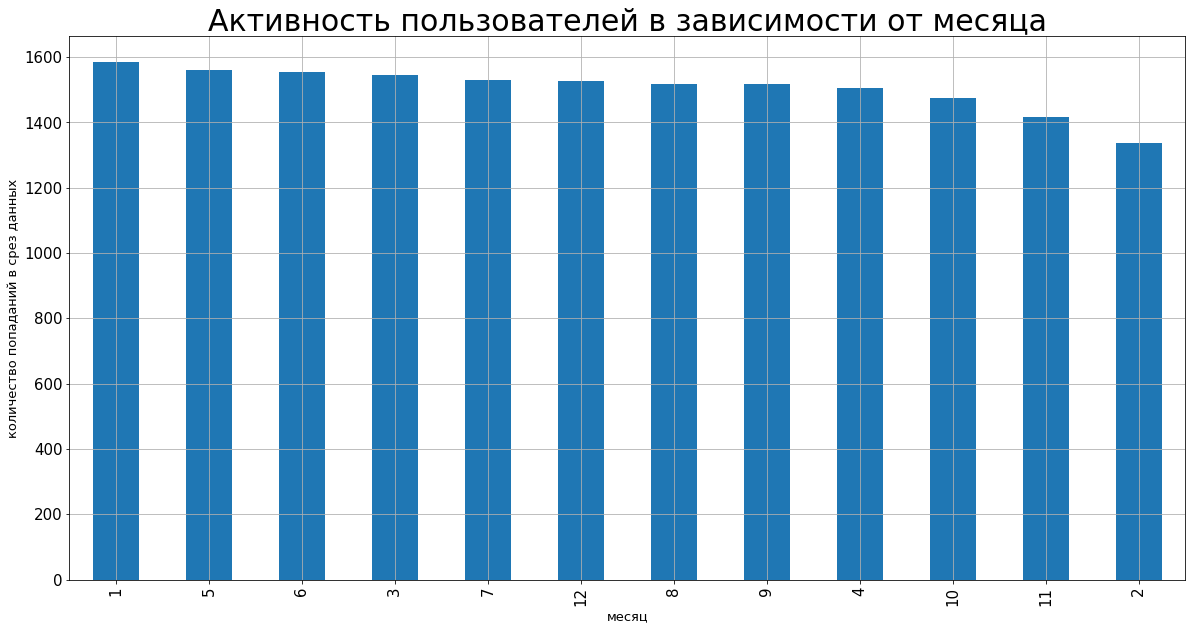

In [ ]:
rides_go['month'].value_counts().plot(kind = 'bar', grid = True, figsize = (20,10), fontsize=15) # визуализируем

plt.title('Активность пользователей в зависимости от месяца', fontsize=30)
plt.xlabel('месяц', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

Колебания в течении года есть, но их нельзя назвать значительными и наглядными (особенно если учеть, что мы можем наблюдать только один год).

То есть мы не можем сказать, что зимой пользователи менее активны, чем летом. Что логично, так как города, предложенные нам на исследования, находятся в разных климатических условиях. Возможно, мы сумеем обнаружить сезонное колебания в рамках одного города после объединения датасетов, но так как подобной задачи в нашем исследовании не стоит, то дополнитльено этот вопрос рассматривать необходимости нет.

***Выводы***

Наиболее популярен сервис в Пятигорске, наименее - в Москве. Это может быть связано с высоким уровнем конкуренции в крупных городах, и особенно таких, как Москва.

54.4% пользователей не используют подписку, причем перевес таких пользователей хорошен выражен везде, кроме Москвы (где доли пользователей двух типов равны) и Омска (где перевес есть, но не столь заметный).

Минимальный возраст пользователя составил 12 лет, максимальный - 43. "Нормальным" возрастом пользователя может счиаться от 13 до 37, но большинство пользователей - люди возрастом 22-28 лет. Средний практически совпадает с медианным, и они составляют 25 лет. Стандартное отклонение невелико, что говорит о хорошем качестве выборки в плане распредения по возрастам. Распределение по возрастам среди пользователей с подпиской и без схожи между собой (с учетом количеств) и стремяться к нормальному.

Максимальное расстояние, на которое брали самокат в аренду, составило 7.2 км, минимальное - меньше метра. Следует взглянуть на данные строки дополнительно. Однако возможно, что первый пользователь брал самокат сразу на несколько поездок в разные точки, а второй - не разобрался с сервисом либо у него закончился баланс на счету.
Распределение расстояния за одну поездку в целом похоже на нормальное, однако имеет второй пик в начале. Возможно. он вызван теми самыми пользователями из Пятигорска, ведь данный город меньше по размеру, чем остальные, поэтому и большим расстояниям взяться неоткуда, но пользователи оттуда достаточно активны. Поэтому необходимо взглянуть на данные строки после объединения таблиц дополнительно.
Стандартное отклонение расстояния за одну поездку большое (что может быть вызвано тем самым вторым пиком в начале). Среднее и медиана отличаются ненамного и составляют около трех километров. Нормальными можно считать поездки от 800 метров до 5.6 км, а основная масса пользователей совершают поездки от 2.5 до 3.8 км.

Стандартное отклонение по времени поездок велико, что говорит о неравномерности выборки, но при этом среднее и медиана отличаются мало и составляют приблизительно 18 минут. Нормальными можно считать поездки от 3 до 34 минут, но основное большинство пользователей тратит на одну поездку 3.67 до 21.75 минут.
Также обнаружены аномалии - трата всего половины минуты на преодоление расстояний от 4 до 7.2 км, поэтому потенциально необходимо будет исключить строки со значением `'duration'` = 0.5.

Явных изменений сезонной активности обнаружно не было. Вероятно это связано с разнообразием климатических условий представленных на исследования городов и недостаточностью данных (мы имеем наблюдения лишь за один год).

Совокупный портрет среднестатистического пользователя: девушка по имени Анна или Мария, либо парень с именем Дмитрий или Александр, возрастом 25 лет из Пятигорска, предпочитающий пользоваться сервисом без подписки и совершающий поездки около трех километров за раз, тратящий на нее 18 минут.

#### Объединение данных

Для дальнейшей работы нам необходимо объединить три имеющихся датасета в один, а также после создать новые датафреймы на его основе, чтобы лучше изучить данные пользователей с и без подписки, так как их "потребительсеое поведение" и "финансовые параметры для компании" отличаются.

##### Объединение датасетов

Так как у нас есть "общие" для нескольких датасетов столбцы, для объелинения будем использовать метод merge().

Но перед этим заново выведем общую информацию об объединяемых датасетах, для того, чтобы вспонить названия данных столбцов, убедиться в совпадении типов данных в указанных столбцах, а также использовать ее для последующей проверки успешности объединения.

In [ ]:
users_go.info() # пользователи

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   user_id            1534 non-null   int64   
 1   name               1534 non-null   object  
 2   age                1534 non-null   int64   
 3   city               1534 non-null   object  
 4   subscription_type  1534 non-null   category
dtypes: category(1), int64(2), object(2)
memory usage: 49.7+ KB


In [ ]:
rides_go.info() # поездки

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   user_id        18068 non-null  int64         
 1   distance       18068 non-null  float64       
 2   duration       18068 non-null  float64       
 3   duration_ceil  18068 non-null  int64         
 4   date           18068 non-null  datetime64[ns]
 5   month          18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 847.1 KB


In [ ]:
subscriptions_go.info() # тарифы

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   subscription_type  2 non-null      category
 1   minute_price       2 non-null      int64   
 2   start_ride_price   2 non-null      int64   
 3   subscription_fee   2 non-null      int64   
dtypes: category(1), int64(3)
memory usage: 302.0 bytes


Начнем с объединения самых крупных из датасетов `'users_go'` (информация о пользователях) и `'rides_go'`(информация об их поездках). Объединять будем по столбцу `'user_id'`.

In [ ]:
data = users_go.merge(rides_go, on='user_id', how='outer')

In [ ]:
data.head(20) # проверка 1

,user_id,name,age,city,subscription_type,distance,duration,duration_ceil,date,month
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,26,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,16,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,7,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,19,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,27,2021-08-28,8
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,17,2021-10-09,10
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,15,2021-10-19,10
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,24,2021-11-06,11
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,16,2021-11-14,11
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,16,2021-11-22,11


In [ ]:
data.info() # проверка 2

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  category      
 5   distance           18068 non-null  float64       
 6   duration           18068 non-null  float64       
 7   duration_ceil      18068 non-null  int64         
 8   date               18068 non-null  datetime64[ns]
 9   month              18068 non-null  int64         
dtypes: category(1), datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 1.4+ MB


Объединенный датафрейм содержит в себе столбцы обоих объединяемых датасетов, количество строк у исходного `'rides_go'` и новосозданного `'data'` совпадают, пропусков не имеется. То есть объединение произошло успешно.

Переходим к присоединению датасета `'subscriptions_go'`. Объединять будем по столбцу с указанием типа подписки `'subscription_type'`.

In [ ]:
data = data.merge(subscriptions_go, on='subscription_type', how='outer')

In [ ]:
data.head(20) # проверка 1

,user_id,name,age,city,subscription_type,distance,duration,duration_ceil,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,7,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,27,2021-08-28,8,6,0,199
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,17,2021-10-09,10,6,0,199
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,15,2021-10-19,10,6,0,199
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,24,2021-11-06,11,6,0,199
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,16,2021-11-14,11,6,0,199
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,16,2021-11-22,11,6,0,199


In [ ]:
data.info() # проверка 2

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  category      
 5   distance           18068 non-null  float64       
 6   duration           18068 non-null  float64       
 7   duration_ceil      18068 non-null  int64         
 8   date               18068 non-null  datetime64[ns]
 9   month              18068 non-null  int64         
 10  minute_price       18068 non-null  int64         
 11  start_ride_price   18068 non-null  int64         
 12  subscription_fee   18068 non-null  int64         
dtypes: category(1), datetime64[ns](1), float64(2), int64(7), obje

К датафрейму `'data'` добавились столбцы с информацией о тарифах, количество строк с информацией до и после совпадает, пропусков не появилось. То есть объединение прошло успешно.

И еще раз взглянем на аномальные по продолжительности поездок строки, чтобы попытаться понять особенности появления.

In [ ]:
data[data['duration'] == 0.5].sort_values(by='distance')

,user_id,name,age,city,subscription_type,distance,duration,duration_ceil,date,month,minute_price,start_ride_price,subscription_fee
15132,1325,Амалия,36,Сочи,free,4030.308008,0.5,1,2021-12-22,12,8,50,0
17909,1524,Матвей,32,Москва,free,4103.998874,0.5,1,2021-06-18,6,8,50,0
10692,1006,Эльмира,25,Ростов-на-Дону,free,4106.278268,0.5,1,2021-10-31,10,8,50,0
9698,937,Родион,22,Ростов-на-Дону,free,4169.066800,0.5,1,2021-12-12,12,8,50,0
14342,1268,Юлия,26,Краснодар,free,4177.139336,0.5,1,2021-06-09,6,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14574,1285,Станислав,27,Пятигорск,free,6316.574814,0.5,1,2021-09-25,9,8,50,0
13701,1224,Александр,25,Пятигорск,free,6414.516026,0.5,1,2021-07-15,7,8,50,0
11385,1057,Адель,26,Москва,free,6601.197575,0.5,1,2021-02-07,2,8,50,0
17242,1477,Ян,17,Сочи,free,6724.932981,0.5,1,2021-01-12,1,8,50,0


In [ ]:
len(data[data['duration'] == 0.5].query('subscription_type == "free"'))

95

Данная аномалия характерна только для пользователей без подписки. Возникала у пользователей разных возрастов и в разных городах и месяцах, но все поездки составили более 4 км. Возможно, это действительно была какая-то акция.

***Выводы***

Объединение трех исходных датасетов (`'users_go'`, `'rides_go'` и `'subscriptions_go'`) в один новый датафрейм `'data'` прошло успешно.

Аномалии времени (полминуты для расстояния более 4 км) оказались характерны только для пользователей без подписки.

##### Создание новых датафреймов

Теперь создадим новые датафреймы, разделив пользователей по наличию/отсутствию подписки.

Но для начала посчитаем, сколько у нас пользователей и поездок каждого типа, для последующих проверок.

In [ ]:
len(data.loc[data['subscription_type'] == 'ultra']['user_id'].unique()) # количество пользователей с подпиской

699

In [ ]:
len(data.loc[data['subscription_type'] == 'ultra']['user_id']) # количество их поездок

6500

In [ ]:
len(data.loc[data['subscription_type'] == 'ultra']['user_id'])\
/len(data.loc[data['subscription_type'] == 'ultra']['user_id'].unique())

9.298998569384835

На одного пользователя с подпиской приходится 9.3 поездки. Посмотрим, насколько активны пользователи без подписки.

In [ ]:
len(data.loc[data['subscription_type'] == 'free']['user_id'].unique()) # количество пользователей без подписки

835

In [ ]:
len(data.loc[data['subscription_type'] == 'free']['user_id']) # количество их поездок

11568

In [ ]:
len(data.loc[data['subscription_type'] == 'free']['user_id'])\
/len(data.loc[data['subscription_type'] == 'free']['user_id'].unique())

13.853892215568862

Группы пользователей с подпиской и без получились разного размера, что будет необходимо учесть далее при проверке теорий.

Пользователей без подписок больше (835 против 699), и поездок они также совершают больше - 13.9 поездок на пользователя против 9.3.

Хорошо это или плохо для компании заказчика - узнаем позже, когда подсчитаем финансовые вложения каждой из групп. А пока вернемся к созданию отдельных датафреймов для каждой из групп.

In [ ]:
data_ultra = data.query('subscription_type == "ultra"') # создание датафрейма пользователей с подпиской

In [ ]:
data_ultra.head() # проверка 1

,user_id,name,age,city,subscription_type,distance,duration,duration_ceil,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,7,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,27,2021-08-28,8,6,0,199


In [ ]:
data_ultra.info() # проверка 2

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6500 entries, 0 to 6499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            6500 non-null   int64         
 1   name               6500 non-null   object        
 2   age                6500 non-null   int64         
 3   city               6500 non-null   object        
 4   subscription_type  6500 non-null   category      
 5   distance           6500 non-null   float64       
 6   duration           6500 non-null   float64       
 7   duration_ceil      6500 non-null   int64         
 8   date               6500 non-null   datetime64[ns]
 9   month              6500 non-null   int64         
 10  minute_price       6500 non-null   int64         
 11  start_ride_price   6500 non-null   int64         
 12  subscription_fee   6500 non-null   int64         
dtypes: category(1), datetime64[ns](1), float64(2), int64(7), object

In [ ]:
data_free = data.loc[data['subscription_type'] == 'free'] # создание датафрейма пользователей без подписки

In [ ]:
data_free.head() # проверка 1

,user_id,name,age,city,subscription_type,distance,duration,duration_ceil,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,15,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,17,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,21,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,10,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,18,2021-02-14,2,8,50,0


In [ ]:
data_free.info() # проверка 2

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11568 entries, 6500 to 18067
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11568 non-null  int64         
 1   name               11568 non-null  object        
 2   age                11568 non-null  int64         
 3   city               11568 non-null  object        
 4   subscription_type  11568 non-null  category      
 5   distance           11568 non-null  float64       
 6   duration           11568 non-null  float64       
 7   duration_ceil      11568 non-null  int64         
 8   date               11568 non-null  datetime64[ns]
 9   month              11568 non-null  int64         
 10  minute_price       11568 non-null  int64         
 11  start_ride_price   11568 non-null  int64         
 12  subscription_fee   11568 non-null  int64         
dtypes: category(1), datetime64[ns](1), float64(2), int64(7), o

Количество строк в новых датафреймах совпадает с соответствующими в исходном датафрейме. "Разбиение по группам" прошло успешно.

***Выводы***

Пользователей без подписок больше (835 против 699), и поездок они также совершают больше - 13.9 поездок на пользователя против 9.3.

Создание новых датафреймов (`'data_ultra'` - с данными пользователей с подпиской и  `'data_free'` - без подписки) на основе ранее созданного объединенного датафрейма `'data'` прошло успешно.

##### Визуализация

Теперь, когда мы получили несколько сводных датафреймов отдельно на пользователей с подпиской и без, мы можем изучить их поведение касательно поездок. А именно расстояние и время поездок, характерное для каждой из групп.

Начнем с продолжительности поездок (пока полное, без исключений аномально коротких поездок).

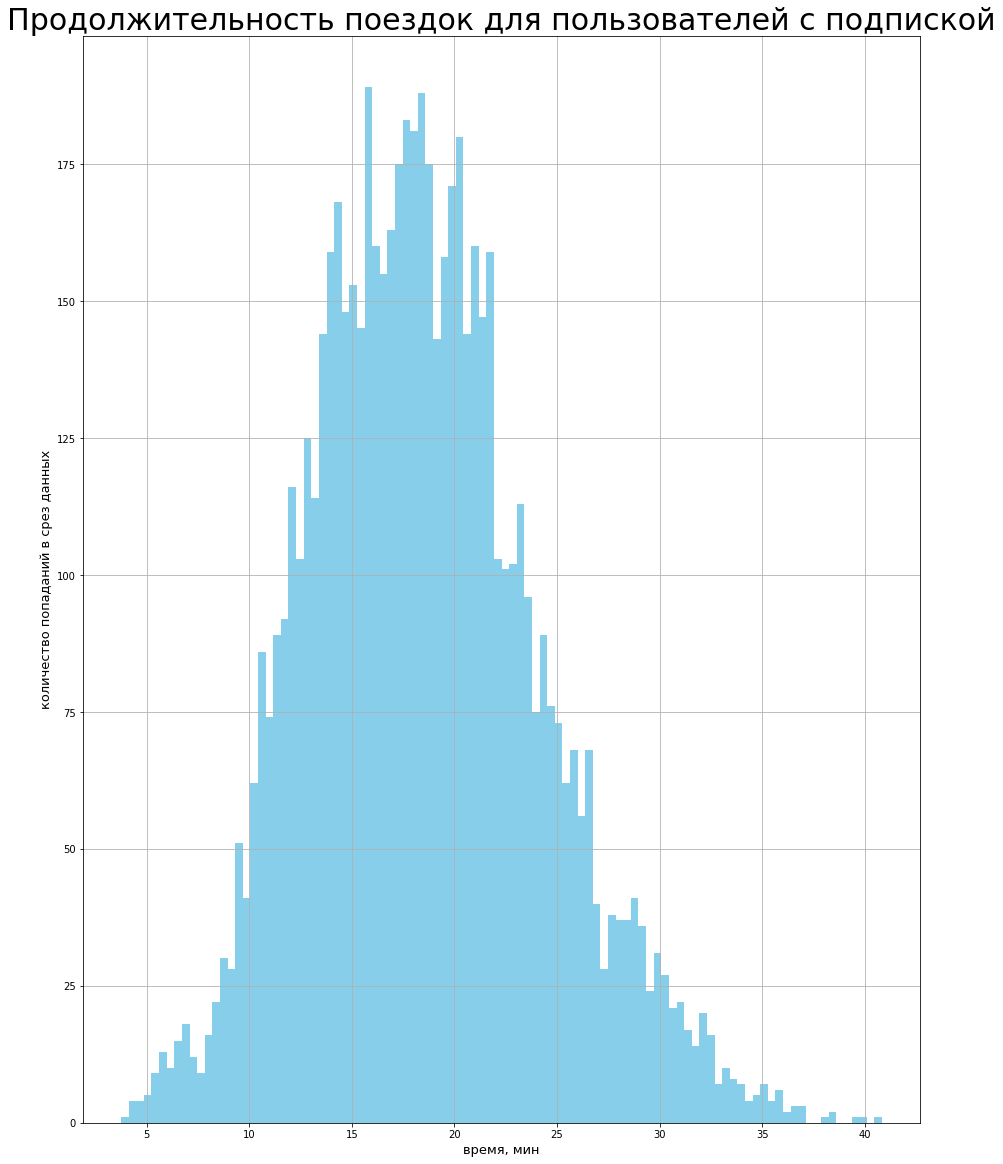

In [ ]:
data_ultra['duration'].hist(figsize=(15,20), color='skyblue', bins = 100, grid = True) # гистограмма для подписчиков

plt.title('Продолжительность поездок для пользователей с подпиской', fontsize=30)
plt.xlabel('время, мин', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

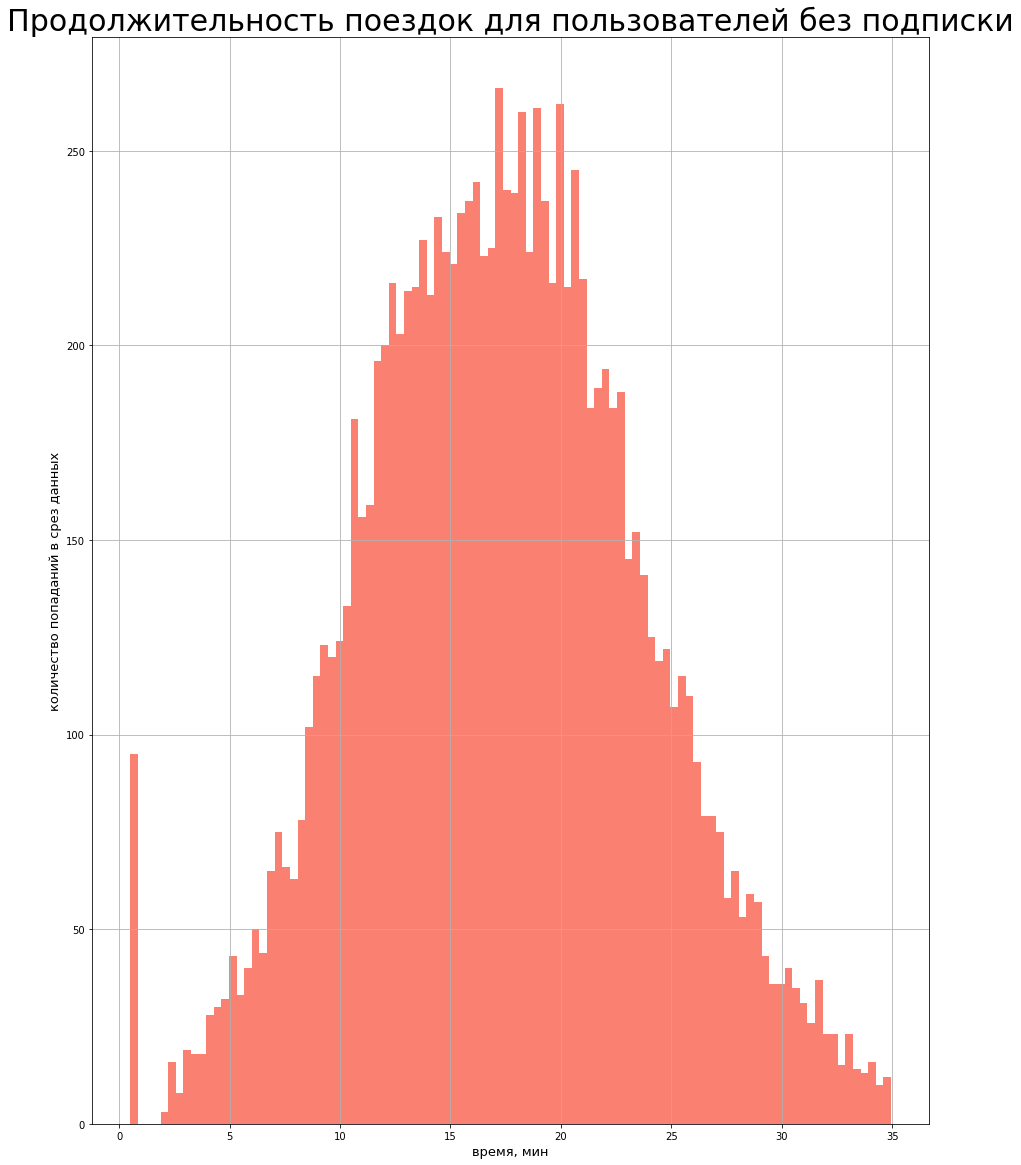

In [ ]:
data_free['duration'].hist(figsize=(15,20), color='salmon', bins = 100, grid = True) # гистограмма для неподписчиков

plt.title('Продолжительность поездок для пользователей без подписки', fontsize=30)
plt.xlabel('время, мин', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

Распределение поездок для обеих групп выглядит достаточно похоже, не считая ранее видимого пика на полминуты в начале у пользователей без подписки. Но для лучшего сравнения сведем две гистограммы вместе.

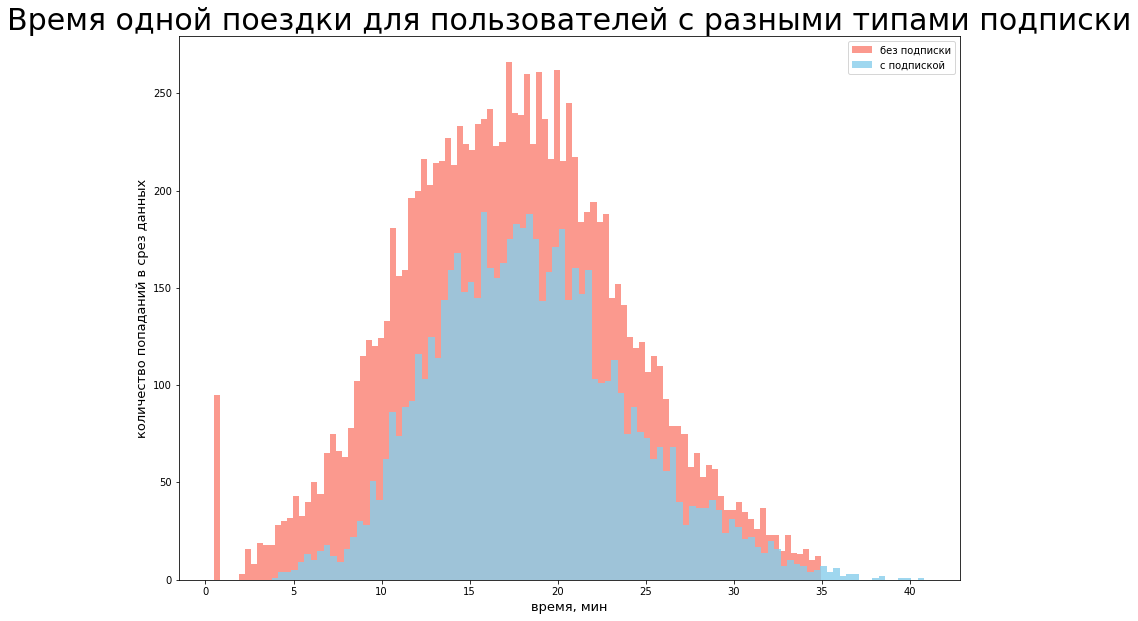

In [ ]:
plt.figure(figsize=(14, 10))

plt.hist(data_free['duration'],\
         bins=100, color='salmon', alpha=0.8, label='без подписки')
plt.hist(data_ultra['duration'],\
         bins=100, color='skyblue', alpha=0.8, label='с подпиской')

plt.title('Время одной поездки для пользователей с разными типами подписки', fontsize=30)
plt.xlabel('время, мин', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.legend(loc='best')
plt.show()

Распределение действительно похоже (и схоже с тем, что мы видели ранее, без деления на группы). Однако стало заметно, что самые быстрые по времени из поездок были совершены пользователями без подписки, а самые продолжительные - пользователями с подпиской. Возможно, это связано с тем, что имеющим подписку пользователям надо было меньше волноваться за конечную стоимость поездки.

Теперь взглянем на расстояния для каждой из групп.

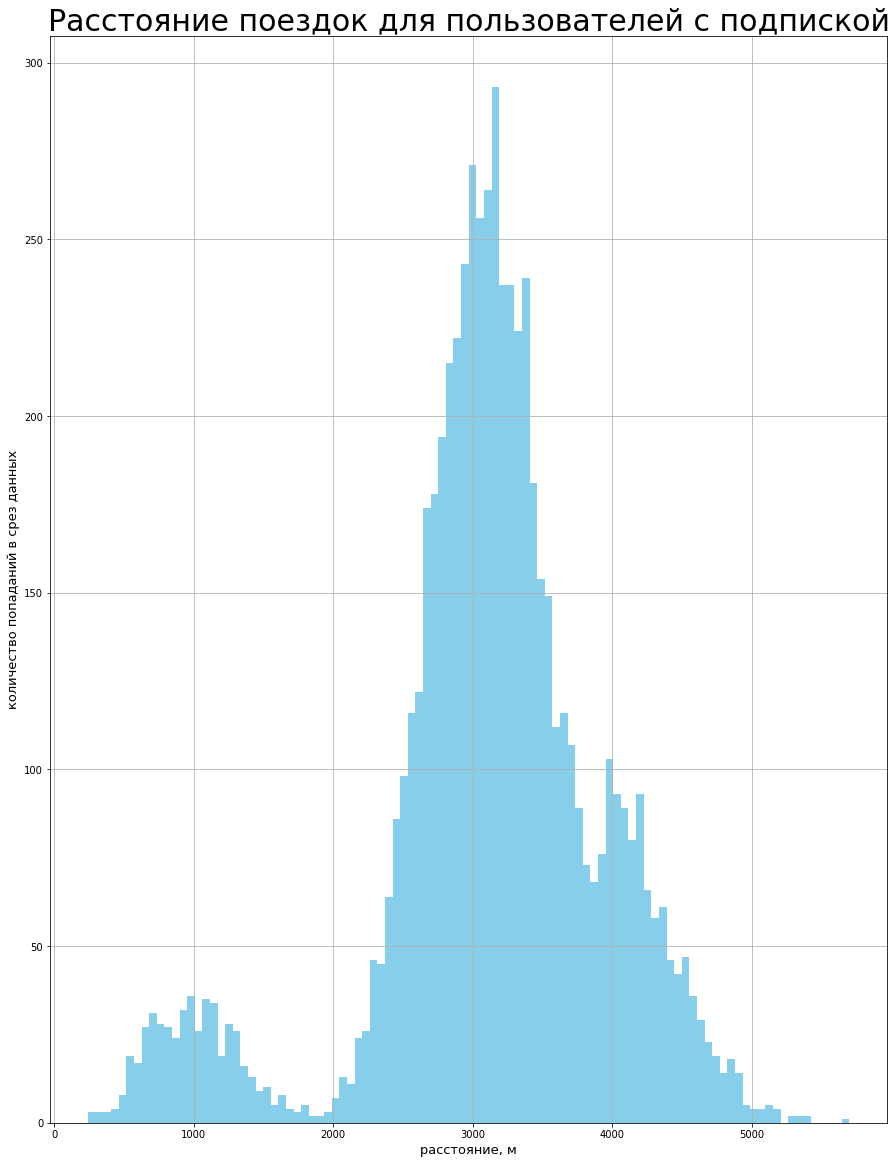

In [ ]:
data_ultra['distance'].hist(figsize=(15,20), color='skyblue', bins = 100, grid = True) # гистограмма для подписчиков

plt.title('Расстояние поездок для пользователей с подпиской', fontsize=30)
plt.xlabel('расстояние, м', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

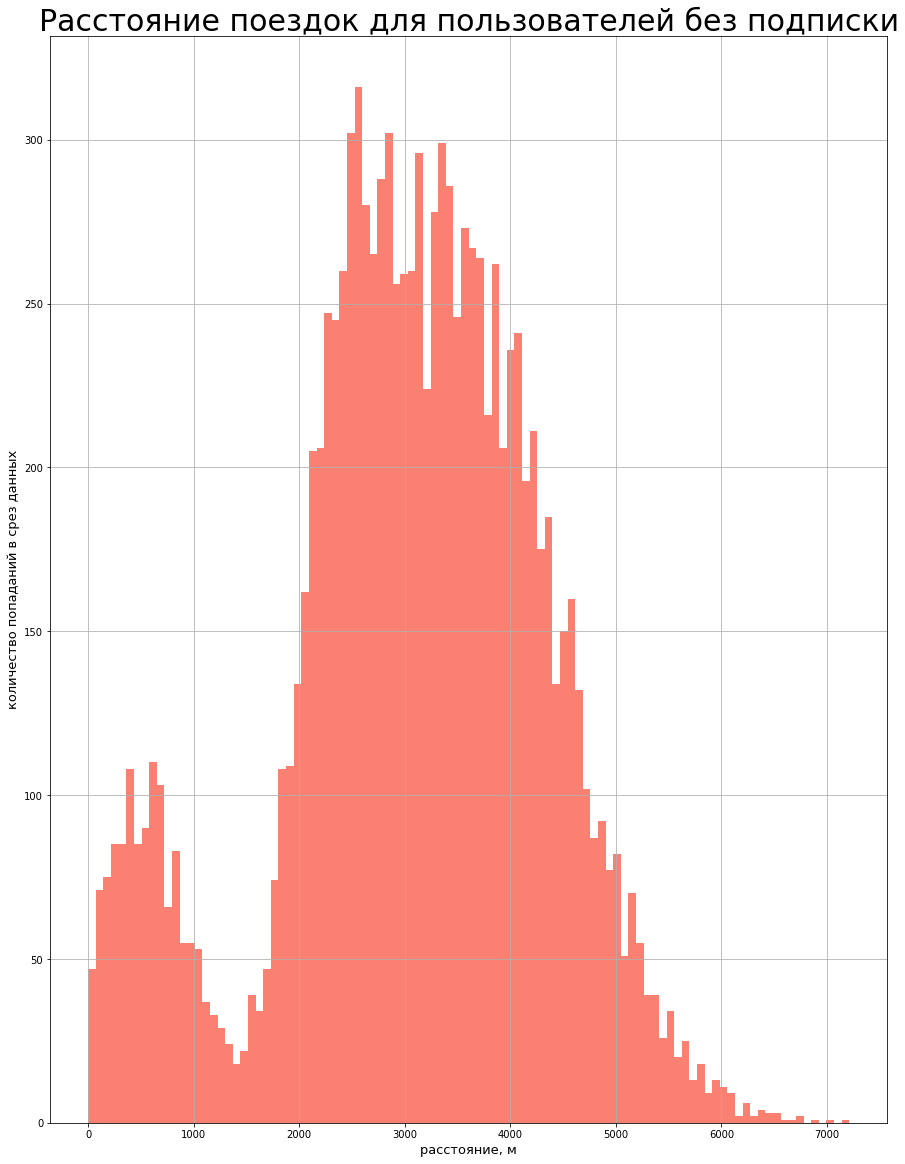

In [ ]:
data_free['distance'].hist(figsize=(15,20), color='salmon', bins = 100, grid = True) # гистограмма для неподписчиков

plt.title('Расстояние поездок для пользователей без подписки', fontsize=30)
plt.xlabel('расстояние, м', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

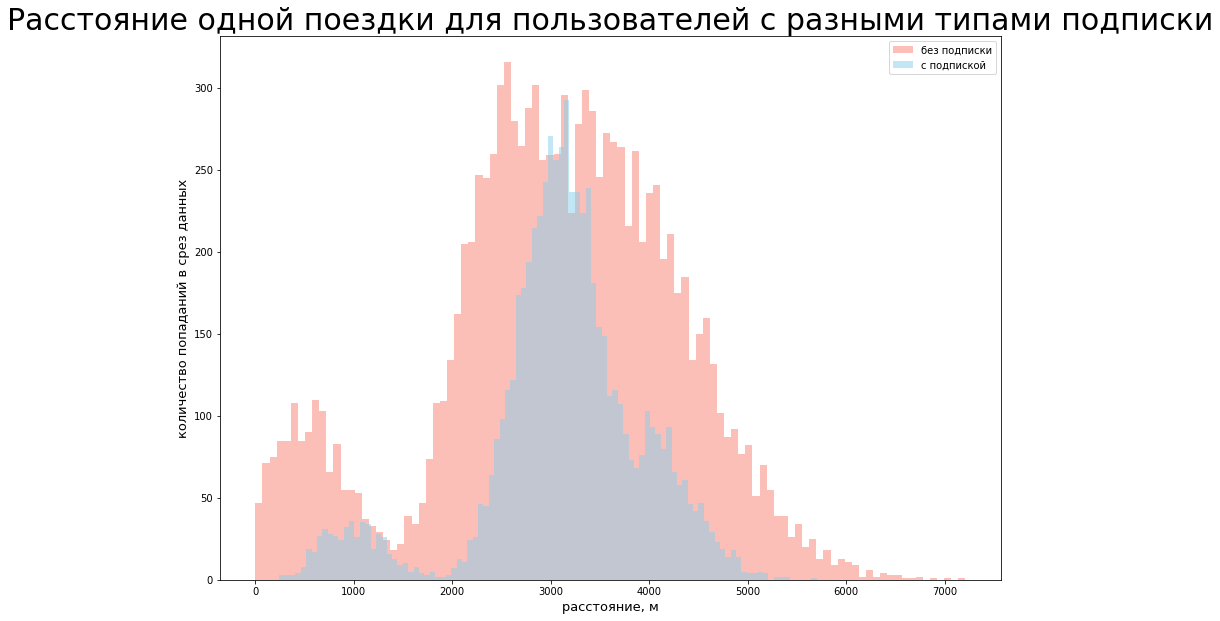

In [ ]:
plt.figure(figsize=(14, 10))

plt.hist(data_free['distance'], bins=100, color='salmon', alpha=0.5, label='без подписки')
plt.hist(data_ultra['distance'], bins=100, color='skyblue', alpha=0.5, label='с подпиской')

plt.title('Расстояние одной поездки для пользователей с разными типами подписки', fontsize=30)
plt.xlabel('расстояние, м', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)
plt.legend(loc='best')

plt.show()

Обе гистограммы также выглядят похоже, и даже обе имеют второй пик в начале. Но вторая гистограмма (для неподписчиков) заметно шире первой (с подписчиками). Возможно, пользователи с подпиской используют самокат регулярно для одних и тех же маршрутов, в то время часть неподписчиков предпочитает взять самокат лишь тогда, когда расстояние слишком большое, чтобы идти пешком и нет альтернативного транспорта.

Посмотрим на эти пики в начале гистограмм.

In [ ]:
data_ultra.query('distance < 2000')

,user_id,name,age,city,subscription_type,distance,duration,duration_ceil,date,month,minute_price,start_ride_price,subscription_fee
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,7,2021-04-20,4,6,0,199
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,16,2021-11-22,11,6,0,199
20,2,Станислав,31,Омск,ultra,923.007439,6.914760,7,2021-08-03,8,6,0,199
47,4,Константин,26,Ростов-на-Дону,ultra,724.559572,11.811399,12,2021-11-14,11,6,0,199
73,7,Игорь,23,Омск,ultra,1609.907996,13.330844,14,2021-04-09,4,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6441,693,Ксения,20,Омск,ultra,710.275448,9.029358,10,2021-03-12,3,6,0,199
6448,693,Ксения,20,Омск,ultra,1523.666976,12.155455,13,2021-11-09,11,6,0,199
6449,694,Алия,29,Краснодар,ultra,773.352502,11.017441,12,2021-02-06,2,6,0,199
6451,694,Алия,29,Краснодар,ultra,997.162454,11.849036,12,2021-02-24,2,6,0,199


In [ ]:
data_free.query('distance < 1500')

,user_id,name,age,city,subscription_type,distance,duration,duration_ceil,date,month,minute_price,start_ride_price,subscription_fee
6501,700,Айдар,22,Омск,free,846.932642,16.234663,17,2021-02-01,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,10,2021-02-10,2,8,50,0
6511,700,Айдар,22,Омск,free,288.974241,4.788112,5,2021-07-18,7,8,50,0
6524,701,Иван,31,Екатеринбург,free,731.410111,6.657051,7,2021-06-02,6,8,50,0
6527,701,Иван,31,Екатеринбург,free,1133.584211,6.250941,7,2021-07-17,7,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18031,1532,Алексей,26,Тюмень,free,303.787850,7.792490,8,2021-05-21,5,8,50,0
18037,1532,Алексей,26,Тюмень,free,662.468186,9.528773,10,2021-11-18,11,8,50,0
18043,1533,Степан,22,Краснодар,free,310.488247,10.642389,11,2021-02-21,2,8,50,0
18049,1533,Степан,22,Краснодар,free,1034.998188,6.299996,7,2021-06-23,6,8,50,0


Подобные короткие поездки характерны как для пользователей с подпиской, так и без, разных возрастов и из разных городов, а также в разное время года (а не только зимой).

Количество строк слишком велико для ошибки. А некоторые пользователи попадали в выборки с малым расстоянием по несколько раз. Некоторые строки выглядит странно. Например, пользователь без подписки Айдар с id 700 в феврале потратил сначала 16 минут, чтобы проехать 847 метров, а спустя десять дней - чуть менее 10 минут для почти в полтора раза меньшего расстояния. А подписчик Кира (id 1) в разные месяцы на схожее расстояние затратила в два раза отличающееся время.

Но, как мы уже упоминали ранее, на это может влиять ограничение скорость по законодательству, дорожная обстановка и погодные условия. Поэтому, принимая во внимание все это, приходится принять, что возможно, для некоторой весомой части пользователей действительно характерны короткие поездки.

***Выводы***

Распределение времени поездок у двух групп пользователей (с подпиской и без) похоже (и схоже с тем, что мы видели ранее, без деления на группы), за исключением ранее видимого пика в полминуты у неподписчиков. Самые быстрые по времени из поездок (даже без учета указанных аномалий) были совершены пользователями без подписки, а самые продолжительные - пользователями с подпиской. Возможно, это связано с тем, что имеющим подписку пользователям надо было меньше волноваться за конечную стоимость поездки.

Гистограммы распределения  расстояния для обеих групп пользователей также выглядят похоже, и даже обе имеют второй пик в начале. Но вторая гистограмма (для неподписчиков) заметно шире первой (с подписчиками). Возможно, пользователи с подпиской используют самокат регулярно для одних и тех же маршрутов, в то время часть неподписчиков предпочитает взять самокат лишь тогда, когда расстояние слишком большое, чтобы идти пешком и нет альтернативного транспорта.

Пики в начале гистограмм распределения расстояния поездок вероятно действительно связаны с необходимостью части регулярных пользователей в коротких поездках.

***Выводы***

Создан объединенный датафрейм `'data'` на основе трех ранее полученных датасетов (`'users_go'`, `'rides_go'` и `'subscriptions_go'`). Также для удобства в дальнейшей работе на его основе созданы разбившие на две группы пользовтелей новые датафреймы `'data_ultra'` (с данными пользователей с подпиской) и  `'data_free'` (без подписки).

Объединение трех исходных  в один новый датафрейм  прошло успешно.

Аномалии времени (полминуты для расстояния более 4 км) оказались зарактерны только для пользователей без подписки.

Распределение времени поездок у двух групп пользователей (с подпиской и без) похоже (и схоже с тем, что мы видели ранее, без деления на группы), за исключением ранее видимого пика в полминуты у неподписчиков. Самые быстрые по времени из поездок (даже без учета указанных аномалий) были совершены пользователями без подписки, а самые продолжительные - пользователями с подпиской. Возможно, это связано с тем, что имеющим подписку пользователям надо было меньше волноваться за конечную стоимость поездки.

Гистограммы распределения  расстояния для обеих групп пользователей также выглядят похоже, и даже обе имеют второй пик в начале. Но вторая гистограмма (для неподписчиков) заметно шире первой (с подписчиками). Возможно, пользователи с подпиской используют самокат регулярно для одних и тех же маршрутов, в то время часть неподписчиков предпочитает взять самокат лишь тогда, когда расстояние слишком большое, чтобы идти пешком и нет альтернативного транспорта.

Пики в начале гистограмм распределения расстояния поездок вероятно действительно связаны с необходимостью части регулярных пользователей в коротких поездках.

#### Подсчёт выручки

##### Создание агрегированных датафреймов

Оплата происходит каждый раз за поездку, а стоимость подписки списывается раз в месяц. Поэтому считать будем изначально "по пользователям", а чтобы не посчитать дважды за месяц одному и тому же пользователю, создадим агрегированные за месяц по пользователям  датафреймы.

Начнем с подписчиков. Но сначала выведем одного из них, для будущего контроля.

In [ ]:
data_ultra.query('user_id == 1')

,user_id,name,age,city,subscription_type,distance,duration,duration_ceil,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,7,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,27,2021-08-28,8,6,0,199
5,1,Кира,22,Тюмень,ultra,2770.890808,16.650138,17,2021-10-09,10,6,0,199
6,1,Кира,22,Тюмень,ultra,3039.020292,14.927879,15,2021-10-19,10,6,0,199
7,1,Кира,22,Тюмень,ultra,2842.118050,23.117468,24,2021-11-06,11,6,0,199
8,1,Кира,22,Тюмень,ultra,3412.690668,15.238072,16,2021-11-14,11,6,0,199
9,1,Кира,22,Тюмень,ultra,748.690645,15.041884,16,2021-11-22,11,6,0,199


Данный пользователь достаточно активна, что удобно для отслеживания.

Перейдем к агрегированию. Теоретически, от всех данных пользователя можно оставить только его id, но когда будут и иные данные - это нагляднее, и быть может позволит обнаружить интересные особенности (или узнать, например, пользователи из каких городов потратили больше всех денег на аренду самокатов). Тип подписки наи известен (ultra), так что его можно не добавлять. Стоимость старта поездки для подписчиков пока составляет 0 рублей, но чтобы можно было использовать имеющийся код и при изменении тарифов, мы все-таки перенесем этот столбцец тоже.

In [ ]:
finance_ultra = data_ultra.pivot_table(index=['user_id','name','city',\
                                              'subscription_fee','minute_price', 'start_ride_price','month'],\
                                       values=['distance', 'duration','duration_ceil'],\
                                       aggfunc={'distance':['sum', 'count'], 'duration':'sum','duration_ceil':'sum'}) # создание

In [ ]:
#finance_ultra.columns = finance_ultra.columns.droplevel(1) #удалить уровень заголовков

finance_ultra # проверка

distance  \
                                                                              count   
user_id name   city   subscription_fee minute_price start_ride_price month            
1       Кира   Тюмень 199              6            0                1            2   
                                                                     4            1   
                                                                     8            2   
                                                                     10           2   
                                                                     11           3   
...                                                                             ...   
699     Оксана Москва 199              6            0                6            1   
                                                                     8            2   
                                                                     9            2   
                                                                     10           1   
                                                                     12           1   

                                                                                         \
                                                                                    sum   
user_id name   city   subscription_fee minute_price start_ride_price month                
1       Кира   Тюмень 199              6            0                1      7027.511294   
                                                                     4       754.159807   
                                                                     8      6723.470560   
                                                                     10     5809.911100   
                                                                     11     7003.499363   
...                                                                                 ...   
699     Оксана Москва 199              6            0                6      4072.797406   
                                                                     8      7018.324143   
                                                                     9      6364.861911   
                                                                     10     4707.845501   
                                                                     12     3202.890770   

                                                                             duration  \
                                                                                  sum   
user_id name   city   subscription_fee minute_price start_ride_price month              
1       Кира   Тюмень 199              6            0                1      41.416640   
                                                                     4       6.232113   
                                                                     8      44.776802   
                                                                     10     31.578017   
                                                                     11     53.397424   
...                                                                               ...   
699     Оксана Москва 199              6            0                6      16.575991   
                                                                     8      44.281768   
                                                                     9      30.282412   
                                                                     10     15.839579   
                                                                     12     25.217345   

                                                                           duration_ceil  
                                                                                     sum  
user_id name   city   subscription_fee minute_price start_ride_price month                
1       Кира   Тюмень 199              6            0        

In [ ]:
finance_ultra[('distance', 'count')] #выводим столбец в двумя уровнями заголовка

user_id  name    city    subscription_fee  minute_price  start_ride_price  month
1        Кира    Тюмень  199               6             0                 1        2
                                                                           4        1
                                                                           8        2
                                                                           10       2
                                                                           11       3
                                                                                   ..
699      Оксана  Москва  199               6             0                 6        1
                                                                           8        2
                                                                           9        2
                                                                           10       1
                                                           

Такой датафрейм смотрится красиво, но не очень удобен в работе из-за мультииндексов.

Сбросим индексы и переименуем столбцы на более подходящие по смыслу.

In [ ]:
finance_ultra = finance_ultra.reset_index() # сброс

In [ ]:
finance_ultra.columns = ['user_id','name', 'city', 'subscription_fee','minute_price','start_ride_price','month',\
                         'rides_count', 'distance_sum','duration_sum','duration_ceil_sum'] # переименование

In [ ]:
finance_ultra # проверка

,user_id,name,city,subscription_fee,minute_price,start_ride_price,month,rides_count,distance_sum,duration_sum,duration_ceil_sum
0,1,Кира,Тюмень,199,6,0,1,2,7027.511294,41.416640,42
1,1,Кира,Тюмень,199,6,0,4,1,754.159807,6.232113,7
2,1,Кира,Тюмень,199,6,0,8,2,6723.470560,44.776802,46
3,1,Кира,Тюмень,199,6,0,10,2,5809.911100,31.578017,32
4,1,Кира,Тюмень,199,6,0,11,3,7003.499363,53.397424,56
...,...,...,...,...,...,...,...,...,...,...,...
4528,699,Оксана,Москва,199,6,0,6,1,4072.797406,16.575991,17
4529,699,Оксана,Москва,199,6,0,8,2,7018.324143,44.281768,45
4530,699,Оксана,Москва,199,6,0,9,2,6364.861911,30.282412,31
4531,699,Оксана,Москва,199,6,0,10,1,4707.845501,15.839579,16


Разница между суммами округленного и неокругленного времени выглядит небольшой в рамках одного месяца одного пользователя. Но с учетом количества пользователей, погрешность при испольовании получается достаточно существенной.

После преобразования обращаться к столбцам будет гораздо удобнее. Проделаем то же самое для неподписчиков.

In [ ]:
data_free.query('user_id == 700')

,user_id,name,age,city,subscription_type,distance,duration,duration_ceil,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,15,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,17,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,21,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,10,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,18,2021-02-14,2,8,50,0
6505,700,Айдар,22,Омск,free,4342.002254,22.368009,23,2021-02-23,2,8,50,0
6506,700,Айдар,22,Омск,free,3798.334905,18.243756,19,2021-03-03,3,8,50,0
6507,700,Айдар,22,Омск,free,2984.551206,15.424899,16,2021-04-09,4,8,50,0
6508,700,Айдар,22,Омск,free,3360.107141,16.765497,17,2021-06-12,6,8,50,0
6509,700,Айдар,22,Омск,free,2567.543847,11.312160,12,2021-06-23,6,8,50,0


Наш "контрольный" неподписчик Айдар (id 700) оказался даже более активным и регулярным пользователем, чем "контрольная" подписчица Кира (id 1).

In [ ]:
finance_free = data_free.pivot_table(index=['user_id','name','city',\
                                              'subscription_fee','minute_price', 'start_ride_price','month'],\
                                       values=['distance', 'duration','duration_ceil'],\
                                       aggfunc={'distance':['sum', 'count'], 'duration':'sum','duration_ceil':'sum'}) # создание

In [ ]:
finance_free = finance_free.reset_index()  # сброс индексов

In [ ]:
finance_free.columns = ['user_id','name', 'city', 'subscription_fee','minute_price','start_ride_price','month',\
                         'rides_count', 'distance_sum','duration_sum','duration_ceil_sum'] # переименование

In [ ]:
finance_free # проверка

,user_id,name,city,subscription_fee,minute_price,start_ride_price,month,rides_count,distance_sum,duration_sum,duration_ceil_sum
0,700,Айдар,Омск,0,8,50,1,1,2515.690719,14.944286,15
1,700,Айдар,Омск,0,8,50,2,5,13446.659764,85.829845,89
2,700,Айдар,Омск,0,8,50,3,1,3798.334905,18.243756,19
3,700,Айдар,Омск,0,8,50,4,1,2984.551206,15.424899,16
4,700,Айдар,Омск,0,8,50,6,2,5927.650988,28.077657,29
...,...,...,...,...,...,...,...,...,...,...,...
6793,1534,Альберт,Краснодар,0,8,50,6,2,3409.468534,24.812678,26
6794,1534,Альберт,Краснодар,0,8,50,8,2,7622.453034,47.205960,48
6795,1534,Альберт,Краснодар,0,8,50,9,1,4928.173852,22.560373,23
6796,1534,Альберт,Краснодар,0,8,50,11,4,13350.015305,76.342174,78


***Выводы***

Создание агрегированных датафреймов для удобства подсчетов прошло успешно.

##### Подсчет помесячной выручки

Теперь, имея агрегированные датафреймы, мы можем почитать, какую выручку приносит каждый из пользователей за месяц.

In [ ]:
def sum_rev (row):
    try:
        return row['start_ride_price']*row['rides_count'] + row['minute_price']*row['duration_ceil_sum'] + row['subscription_fee']
    except:
        pass

In [ ]:
finance_ultra['revenue_per_month'] = finance_ultra.apply(sum_rev, axis=1) # подписчики

In [ ]:
finance_ultra # проверка

,user_id,name,city,subscription_fee,minute_price,start_ride_price,month,rides_count,distance_sum,duration_sum,duration_ceil_sum,revenue_per_month
0,1,Кира,Тюмень,199,6,0,1,2,7027.511294,41.416640,42,451
1,1,Кира,Тюмень,199,6,0,4,1,754.159807,6.232113,7,241
2,1,Кира,Тюмень,199,6,0,8,2,6723.470560,44.776802,46,475
3,1,Кира,Тюмень,199,6,0,10,2,5809.911100,31.578017,32,391
4,1,Кира,Тюмень,199,6,0,11,3,7003.499363,53.397424,56,535
...,...,...,...,...,...,...,...,...,...,...,...,...
4528,699,Оксана,Москва,199,6,0,6,1,4072.797406,16.575991,17,301
4529,699,Оксана,Москва,199,6,0,8,2,7018.324143,44.281768,45,469
4530,699,Оксана,Москва,199,6,0,9,2,6364.861911,30.282412,31,385
4531,699,Оксана,Москва,199,6,0,10,1,4707.845501,15.839579,16,295


In [ ]:
finance_free['revenue_per_month'] = finance_free.apply(sum_rev, axis=1) # подписчики

In [ ]:
finance_free # проверка

,user_id,name,city,subscription_fee,minute_price,start_ride_price,month,rides_count,distance_sum,duration_sum,duration_ceil_sum,revenue_per_month
0,700,Айдар,Омск,0,8,50,1,1,2515.690719,14.944286,15,170
1,700,Айдар,Омск,0,8,50,2,5,13446.659764,85.829845,89,962
2,700,Айдар,Омск,0,8,50,3,1,3798.334905,18.243756,19,202
3,700,Айдар,Омск,0,8,50,4,1,2984.551206,15.424899,16,178
4,700,Айдар,Омск,0,8,50,6,2,5927.650988,28.077657,29,332
...,...,...,...,...,...,...,...,...,...,...,...,...
6793,1534,Альберт,Краснодар,0,8,50,6,2,3409.468534,24.812678,26,308
6794,1534,Альберт,Краснодар,0,8,50,8,2,7622.453034,47.205960,48,484
6795,1534,Альберт,Краснодар,0,8,50,9,1,4928.173852,22.560373,23,234
6796,1534,Альберт,Краснодар,0,8,50,11,4,13350.015305,76.342174,78,824


Теперь визуализируем выручку за месяц для подписчиков и неподписчиков.

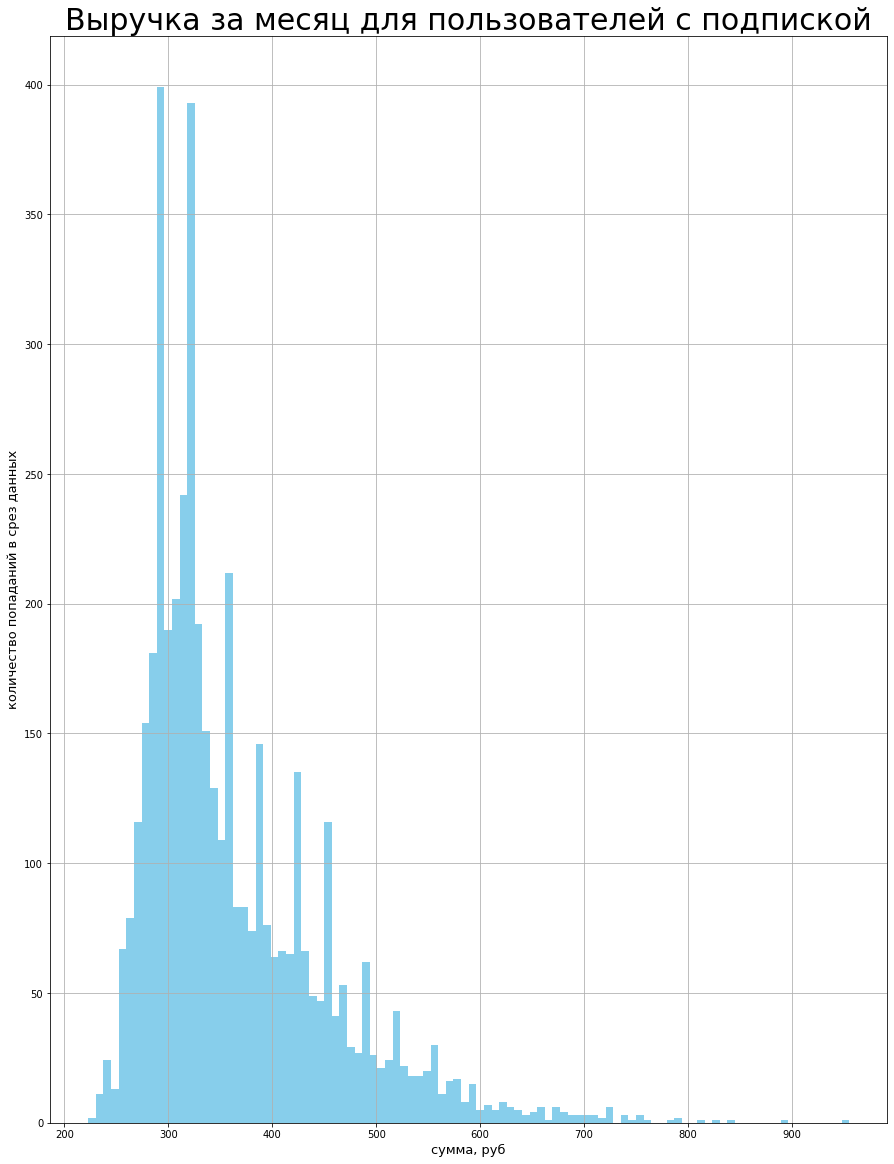

In [ ]:
finance_ultra['revenue_per_month'].hist(figsize=(15,20), color='skyblue', bins = 100, grid = True) # гистограмма для подписчиков

plt.title('Выручка за месяц для пользователей с подпиской', fontsize=30)
plt.xlabel('сумма, руб', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

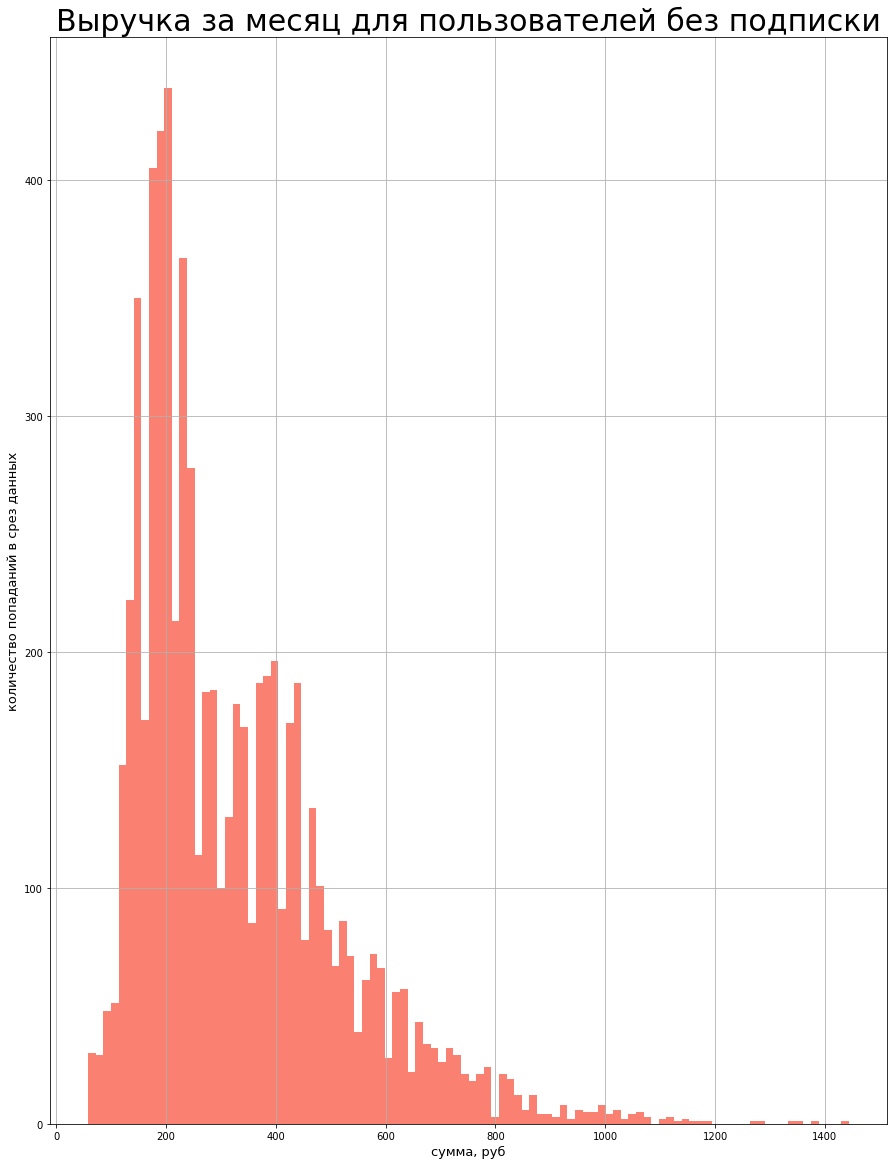

In [ ]:
finance_free['revenue_per_month'].hist(figsize=(15,20), color='salmon', bins = 100, grid = True) # гистограмма для подписчиков

plt.title('Выручка за месяц для пользователей без подписки', fontsize=30)
plt.xlabel('сумма, руб', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)

plt.show()

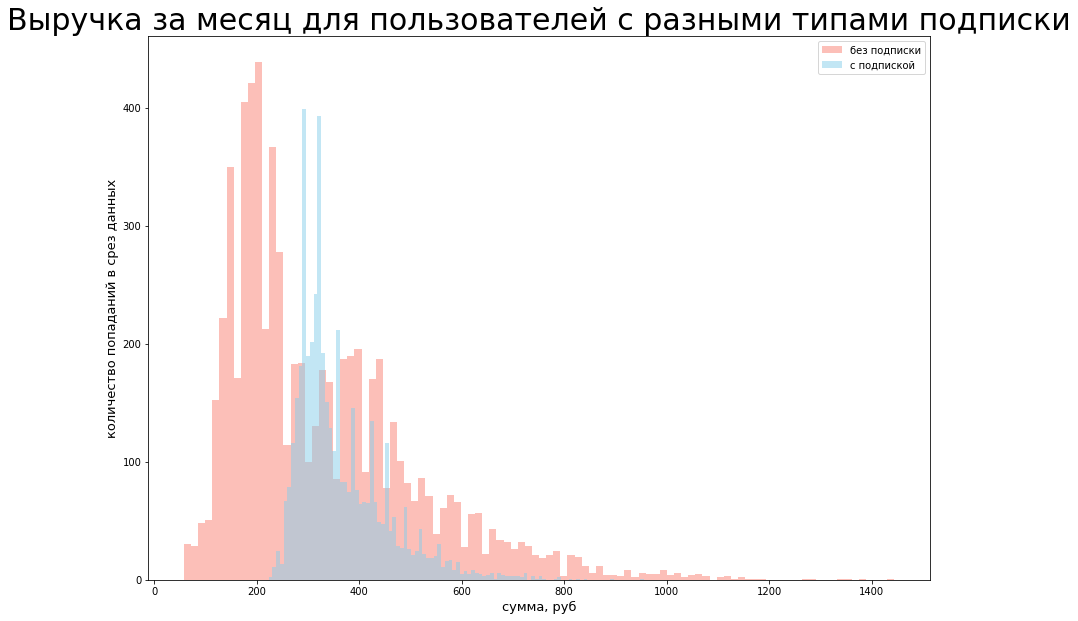

In [ ]:
plt.figure(figsize=(14, 10))

plt.hist(finance_free['revenue_per_month'], bins=100, color='salmon', alpha=0.5, label='без подписки')
plt.hist(finance_ultra['revenue_per_month'], bins=100, color='skyblue', alpha=0.5, label='с подпиской')

plt.title('Выручка за месяц для пользователей с разными типами подписки', fontsize=30)
plt.xlabel('сумма, руб', fontsize=13)
plt.ylabel('количество попаданий в срез данных', fontsize=13)
plt.legend(loc='best')

plt.show()

Центр обеих гистограмм смещен влево. Однако диапазон значений для неподписчиков гораздо шире, чем для подписчиков (плюс подписчикам вовсе невозможно потратить менее 199 рублей в месяц (то есть цены подписки), а не подписчик - менее 50 (то есть цены старта)).

Взглянем на статистическое описание данных.

<AxesSubplot:>

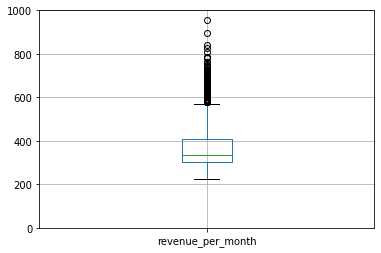

In [ ]:
plt.ylim(0,1000)
finance_ultra.boxplot(column=['revenue_per_month']) # подписчики

In [ ]:
finance_ultra['revenue_per_month'].describe()

count    4533.000000
mean      362.792191
std        88.262737
min       223.000000
25%       301.000000
50%       337.000000
75%       409.000000
max       955.000000
Name: revenue_per_month, dtype: float64

Стандартное отклонение большое, что говорит о неоднородной активности пользователей в выборке. Медиана и среднее таккже сильно отличаются, что еще раз указывает на неоднородность выборки (возможно, это влияние тех аномальных поездок в полминуты).

Обычными тратами для подписчиков можно считать от 223 до 580 рублей в месяц, но основная часть подписчиков приносит от 301 до 409 рублей в месяц. При этом наименьшая выручка с пользователя в месяц составила 223 рубля (это подписка и несколько минут поездки), а самая высокая - 955 рублей.

<AxesSubplot:>

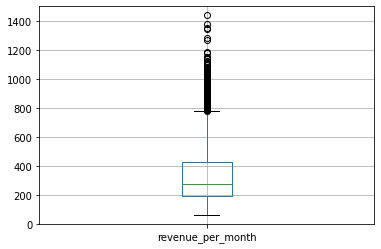

In [ ]:
plt.ylim(0,1500)
finance_free.boxplot(column=['revenue_per_month']) # подписчики

In [ ]:
finance_free['revenue_per_month'].describe()

count    6798.000000
mean      328.641365
std       183.868330
min        58.000000
25%       194.000000
50%       274.000000
75%       428.000000
max      1444.000000
Name: revenue_per_month, dtype: float64

Стандартное отклонение большое (еще большее, чем у пользователей с подпиской), что говорит о неоднородной активности пользователей в выборке. Медиана и среднее таккже сильно отличаются, что еще раз указывает на неоднородность выборки.

Обычными тратами для неподписчиков можно считать от 58 до 800 рублей в месяц, но основная часть подписчиков приносит от 194 до 428 рублей в месяц. При этом наименьшая выручка с пользователя в месяц составила 58 рубля (это цена за старт и минута поездки), а самая высокая - 1444 рублей.

То есть диапазон значений выручки за месяц у подписчиков уже, но минимальная стандартная трата заметно выше, чем у неподписчиков. При этом стандартный максимум подписчиков также ниже, чем у неподписчиков, но ненамного.

***Выводы***

Распределение значений выручки с пользователя в месяц шире у неподписчиков, чем у подписчиков. При этом большие стандартные отклонения и разницы между средним и медианой указывает на неоднородность выборки.

Обычными тратами для подписчиков можно считать от 223 до 580 рублей в месяц (для неподписчиков от 58 до 800), но основная часть подписчиков приносит от 301 до 409 рублей в месяц (неподписчики от 194 до 428). При этом наименьшая выручка с пользователя в месяц составила 223 рубля для подписчика (58 рубля для неподписчика), а самая высокая - 955 рублей (1444 рублей соответственно).

Диапазон значений выручки за месяц у подписчиков уже, но минимальная стандартная трата заметно выше, чем у неподписчиков. При этом стандартный максимум подписчиков также ниже, чем у неподписчиков, но ненамного.

***Выводы***

Для удобства подсчетов были созданы два агрегированных датафрейма.

Распределение значений выручки с пользователя в месяц шире у неподписчиков, чем у подписчиков. При этом большие стандартные отклонения и разницы между средним и медианой указывает на неоднородность выборки. Диапазон значений выручки за месяц у подписчиков уже, но минимальная стандартная трата заметно выше, чем у неподписчиков. При этом стандартный максимум подписчиков также ниже, чем у неподписчиков, но ненамного.

Обычными тратами для подписчиков можно считать от 223 до 580 рублей в месяц (для неподписчиков от 58 до 800), но основная часть подписчиков приносит от 301 до 409 рублей в месяц (неподписчики от 194 до 428). При этом наименьшая выручка с пользователя в месяц составила 223 рубля для подписчика (58 рубля для неподписчика), а самая высокая - 955 рублей (1444 рублей соответственно).

#### Проверка гипотез

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

Уровень значимости alpha будем использовать 0.05.

In [ ]:
alpha = 0.05 # задаём уровень значимости

##### Гипотеза 1: Пользователи с подпиской тратят больше времени на поездки

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверим гипотезу. Используем для этого исходные (неокругленные) данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

Для того, чтобы это проверить, формулируем рабочие гипотезы:

- Нулевая гипотеза: Средние значения затрачиваемого пользователем на одну поездку времени у двух выборок равны.
- Альтернативная гипотеза: Среднее значение затрачиваемого пользователем на одну поездку времени первой (подписчики) выборки больше среднего значения второй (неподписчики) выборки.

In [ ]:
# проводим ttest для двух выборок, в качестве альтернативной используем одностороннюю гипотезу «больше»
results = st.ttest_ind(data_ultra['duration'], data_free.query('duration != 0.5')['duration'],\
                       equal_var=False, alternative='greater')

In [ ]:
results.pvalue

1.6162210195311063e-29

In [ ]:
# сравниваем p-value и уровень значимости
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

Отвергаем нулевую гипотезу


Полученное значение p-value меньше (причем значительно) заданного уровня значимости, поэтому можно отвергнуть нулевую гипотезу. Есть основания говорить, что пользователи с подпиской тратят больше времени на поездки.

***Вывод***

На основании имеющихся данных гипотеза о равенстве средних двух выборок была отвергнута, поэтому есть основания утверждать, что пользователи с подпиской тратят больше времени на поездки.

##### Гипотеза 2: Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку не превышает оптимального с точки зрения износа

Согласно информации заказчика расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверим гипотезу и сделаем выводы.

В данном случае будем использовать проверку односторонней гипотезы.

Для того, чтобы это проверить, формулируем рабочие гипотезы:

- Нулевая гипотеза: Среднее расстояние за одну поездку меньше или равна 3130 м.
- Альтернативная гипотеза: Среднее расстояние за одну поездку больше 3130.

Но посмотрим математическое описание выборки для интереса.

In [ ]:
data_ultra['distance'].describe()

count    6500.000000
mean     3115.445388
std       836.895330
min       244.210438
25%      2785.444017
50%      3148.637229
75%      3560.574425
max      5699.769662
Name: distance, dtype: float64

Среднее выборки составляет 3115 метров, что меньше 3130 метров. Но выборка - лишь часть генеральной совокупности. Поэтому проверка гипотезы ttest-ом может не подтвердить предварительные выводы.

Перейдем к самому тесту.

In [ ]:
distance_optimal = 3130 # расстояние одной поездки, оптимальное с точки зрения износа самоката

In [ ]:
results = st.ttest_1samp(data_ultra['distance'], distance_optimal, alternative='greater')

In [ ]:
results.pvalue

0.9195368847849785

In [ ]:
# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

Нет оснований отвергнуть нулевую гипотезу


Результаты ttest-а согласуются с ранее видимым средним расстояния одной поездки для выборки подписчиков.

Полученное значение p-value больше (причем значительно) заданного уровня значимости, поэтому нет оснований отвергать нулевую гипотезу.

***Вывод***

Исходя из имеющихся данных нет оснований отвергать гипотезу о том, что среднее расстояние за одну поездку, совершаемую пользователем с подпиской, меньше или равно 3130 м. Результаты ttest-а согласуются с ранее видимым средним расстояния одной поездки для выборки подписчиков. Поэтому можно утверждать, что пользователи с подпиской за одну поездку проезжают 3130 метров или менее.

##### Гипотеза 3: Помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

Проверим гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки, и сделаем вывод.

Мы уже видели ранее, что средняя ежемесячной выручки с пользователя у нашей выборки выше у подписчиков, чем неподписчиков (362.8 против 328.6). Сейчас мы это дополнительно подтвердим с помощью ttest-а.

Для того, чтобы это проверить, формулируем рабочие гипотезы:

- Нулевая гипотеза: Среднее значение ежемесячной выручки с пользователя с подпиской равны таковой у пользователей  без подписки.
- Альтернативная гипотеза: Среднее значение ежемесячной выручки у пользователя первой (подписчики) выборки больше среднего значения второй (неподписчики) выборки.

In [ ]:
# проводим ttest для двух выборок, в качестве альтернативной используем одностороннюю гипотезу «больше»
results = st.ttest_ind(finance_ultra['revenue_per_month'], finance_free['revenue_per_month'],\
                       equal_var=False, alternative='greater')

In [ ]:
results.pvalue

8.874140893976874e-40

In [ ]:
# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

Отвергаем нулевую гипотезу


Полученное значение p-value меньше (причем значительно) заданного уровня значимости, поэтому можно отвергнуть нулевую гипотезу. Есть основания говорить, что пользователи с подпиской тратят в сервисе больше денег.

***Вывод***

На основании имеющихся данных гипотеза о том, что среднее значение ежемесячной выручки с пользователя с подпиской равны таковой у пользователей без подписки была отвергнута. Результаты ttest-а согласуются с ранее видимыми средними выручками с пользователя за месяц для выборок подписчиков и неподписчиков. Поэтому есть основания утверждать, что пользователи с подпиской тратят в сервисе больше денег.

##### Ситуационная задача

*Задача*

Представим такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест нам понадобился бы для проверки этой гипотезы?

*Ответ*

Данная задача является примером гипотезы о равенстве двух средних для зависимых (парных) выборок.

Для проверки нам бы потребовался метод scipy.stats.ttest_rel().

Нулевая гипотеза гласит, что количество обращений до и после обновления сервиров осталось прежним либо уменьшилось. Альтернативная - что количество обращений возрасло.

from scipy import stats as st

before = pd.read_csv('...')

after = pd.read_csv('...')

alpha = 0.05 # уровень статистической значимости (мб и 0.01)

results = st.ttest_rel(before, after, alternative='greater')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу о равенстве или снижении количеств обращений')
else:
    print('Не получилось отвергнуть нулевую гипотезу о равенстве или снижении количеств обращений')
    
В зависимости от полученного значения p-value и выбранного уровня значимости мы сможем сделать вывод о состоятельности гипотезы о сохранении или снижении количества обращений в поддержку, а следоватнльно вывод о том, пошло ли на пользу проекту обновление серверов.

***Вывод***

Мы проверили несколько гипотез и установили, что:

- Можно утверждать, что пользователи с подпиской тратят больше времени на поездки.
- Можно утверждать, что пользователи с подпиской за одну поездку проезжают 3130 метров или менее.
- Можно утверждать, что пользователи с подпиской тратят в сервисе больше денег.
- Для изучения гипотезы о снижении количеств обращений после обновления серверов нам бы понадобился метод scipy.stats.ttest_rel() с параметром alternative='greater'.

#### Шаг 7. Распределения

##### Задача 1

Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж.

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.

##### Решение

*Подсказка*

Нужно использовать биномиальное распределение, которое описывает указанную ситуацию. Затем подобрать подходящее значение параметра N для заданного параметра p=0.1 с помощью графиков и метода cdf() , сформулировать вывод и ответ.

Начнем с того, что взлянем на гистограму при 1000 (100*0,1) промокодов.

In [ ]:
p = 0.1 # вероятность продления подписки существующим клиентом

In [ ]:
n = 1000 # со скольки промокодов начнем

In [ ]:
distr = [] # список в котором будете хранить значения распределения

In [ ]:
for k in range(0, n + 1):# строим распределение вероятностей
    choose = factorial(n) / (factorial(k) * factorial(n - k))
    prob = choose * p**k * (1 - p)**(n - k)
    distr.append(prob)

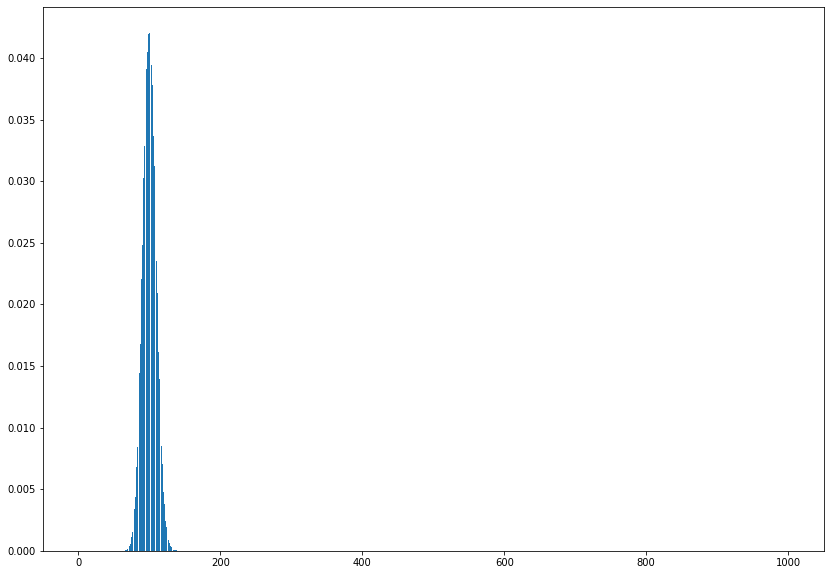

In [ ]:
# построим гистограмму распределения вероятностей
plt.figure(figsize=(14, 10))

plt.bar(range(0, n + 1), distr)

plt.show()

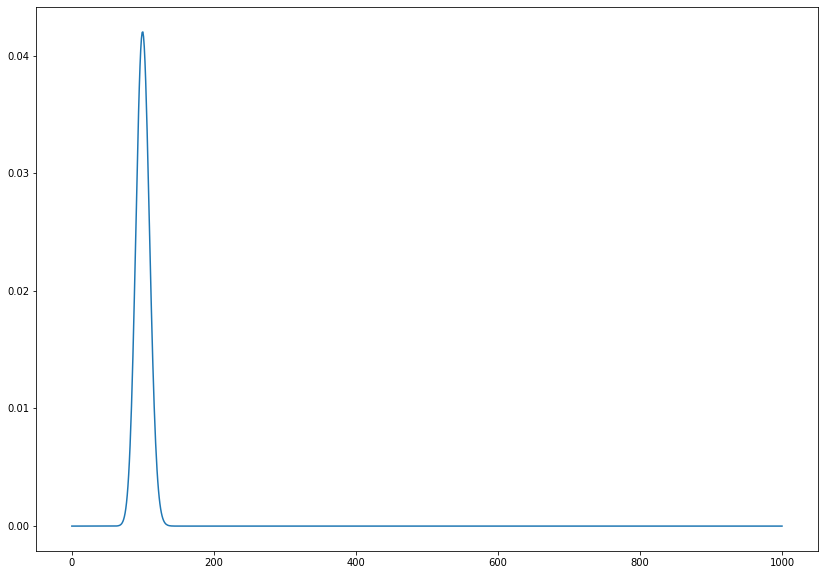

In [ ]:
# построим гистограмму распределения вероятностей

plt.figure(figsize=(14, 10))
plt.plot(range(0, n + 1), distr)
plt.show()

<div class="alert alert-info">
<b>Комментарий студента:</b>

А как тут увеличить размер гистограммы? А ограничить ось x для вывода?
    
Пс при попытке подбора значений, столкнулась с ошибкой, что слишком много знаков после запятой для float. Увы, пока плохо соображаю, как быть иначе((
    
</div>

<div class="alert alert-warning"; style="border-left: 7px solid gold">
<b>⚠️ Комментарий ревьюера, ревью 1</b>

Функция binom.cdf (from scipy.stats import binom) с параметрами k, n, p вернёт тебе долю значений распределения, которые меньше заданной величины k, при n попытках с p вероятностью успехов.
    
Если вдруг все ёще непонятно, пожалуйста, задай вопросы преподавателю по проекту.   

<div class="alert alert-info">
<b>Комментарий студента v.2:</b>

Спасибо! Возможно, это тоже может быть частью допматериала (про в принципе наличие которого я, честно говоря, вовсе забыла к моменту подходу к данным задачам, поэтому мозг и не соображал, видимо, что просто материалов недостаточно, а не я черезчур сильно туплю).
    
Доп материал постараюсь изучить в будущем, пока добавила решение (надеюсь, я правильно поняла, как она работает) через данную функцию и добавила полученные результаты в выводы. График тоже построила по образцу из https://www.codecamp.ru/blog/binomial-distribution-python/ Надеюсь, я правильно поняла, какие параметры надо там задавать.
    
Пс А как "обрезать" гистограмму выше? А то "поле" большое, а пик только вначале, в первой одной пятой. Или так норм, чтоб было видно, что ничего не выбивается, все кучно около пика?
   
<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Комментарий ревьюера, ревью 2</b>


    
✔️ Посмотри ниже, показала данный график только в виде линии, а не столбиков.
    
<a class="tocSkip"></a><s>

</div>

Несмотря на пик около желаемого количества, довольно много шансов недобрать подписчиков. Значит, следует раздать больше промокодов. Но вот сколько именно? Попробуем узнать.

<div class="alert alert-info">
<b>Комментарий студента:</b>

Несмотря на подсказку, я все равно не понимаю, что и как от меня хотят((

Если бы не ошибка с float, можно было бы вручную что-то поискать. Но в таких условиях не очень понятно(( Буду благодарна за дополнительную наводку.
   
</div>

In [ ]:
k = 100 # желаемое количество подписчиков

In [ ]:
binom.cdf(k, n, p) # вероятная доля неудач

0.5265990812951653

In [ ]:
1 - binom.cdf(k, n, p) # вероятная доля успехов

0.4734009187048347

Если мы разошлем 1000 промокодов, то шанс выполнить задачу по продлению подписки хотя бы у 100 подписчиков составляет лишь 47% (при желаемых 95 и выше).

Побробуем подобрать подходящее количество промокодов так, чтобы вероятность неудачи была около 5%.

In [ ]:
binom.cdf(k, 1100, p)

0.17008975275733812

Увеличив исходное представляемое количество промокодов на сто, мы уже добились снижние доли неудачных попыток с 52,7 до 17 %.

Увеличим еще немного.

In [ ]:
binom.cdf(k, 1150, p)

0.07493824563006114

7.5% - мы уже близки к оптимальному количеству промокодов.

In [ ]:
binom.cdf(k, 1170, p)

0.05151491673741622

Раздав 1170 промокдов мы получим шанс неудачи 5.15%. Близко к желаемому, но можно еще чуть-чуть оптимизировать. Ведь на фоне более тысячи промокодов ради того, чтобы удержать хотя бы сотню подписчиков, пара штук особой роли не играет, но повысит наши шансы на успех (плюс нет пределов совершенству).

In [ ]:
binom.cdf(k, 1171, p)

0.0505235199072141

In [ ]:
binom.cdf(k, 1172, p)

0.04954795210203071

1172 промокода - это оптимальное количество, чтобы риск провала составил всего 4.95%

Попробуем примерно визуализировать желаемый результат.

/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


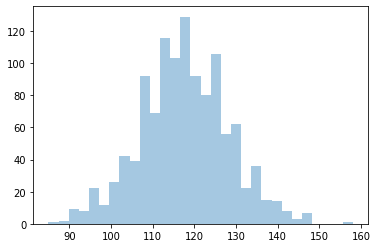

In [ ]:
# библиотеки подключены ранее, повторены на будущее, чтоб знать, какие именно нужны
#from numpy import random
#import matplotlib.pyplot as plt
#import seaborn as sns

#Ось x описывает количество успешных результатов в течение n испытаний,
#а ось y показывает, сколько раз каждое количество успешных результатов произошло в течение size экспериментов.

x = random.binomial(n= 1172 , p= 0.1 , size= 1172)

sns.distplot(x, hist= True, kde= False)

plt.show();

Несмотря на шанс провала плана в 5%, график выглядит многообещающе (что план будет не только выполнен, но и перевыполнен).

*Альтернативный вариант*

(более оптимизированный, но не включен в выводы)

In [ ]:
#функция подсчета

for n in range(1000, 1500):
    if binom.cdf(99, n, p) <= 0.05:
      print("Минимальное количество промокодов: ", n)
      break

Минимальное количество промокодов:  1161


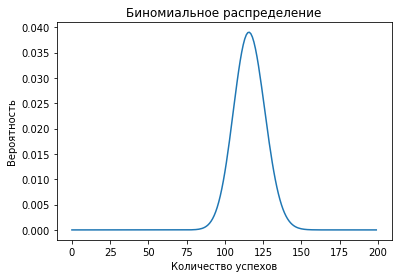

In [ ]:
#строим график

n = 1161  # Количество промокодов
p = 0.10  # Вероятность успеха

# Значения для оси x, вот так можем ограничить ось
x = range(200)

# Значения для оси y
y = binom.pmf(x, n, p)

# Построение графика
plt.plot(x, y)
plt.ylabel("Вероятность")
plt.xlabel("Количество успехов")
plt.title("Биномиальное распределение")
plt.show()

***Вывод***

Чтобы выполнить план (как минимум 100 текущих клиентов продлили подписку) с вероятностью близкой к 95% необходимо раздать 1172 промокода.

##### Задача 2

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

##### Решение

Зададим параметры биномиального распределения

In [ ]:
n = 1000000 # размер рассылки
p = 0.4 # вероятность, что письмо откроют

Зададим математическое ожидание и стандартное отклонение нормального распределения равными таковым у биномиального распределения.

In [ ]:
mu = n * p
sigma = sqrt(n * p * (1 - p))

In [ ]:
# задаём нормальное распределение
distr = st.norm(mu, sigma)

In [ ]:
# считаем вероятность хвоста слева от интересующего количества
result = distr.cdf(399500)

In [ ]:
result*100

15.371708296369768

Вероятность подобного исхода (из 1 млн уведомлений откроют менее 399.5 тыс) составляет 15.37 %

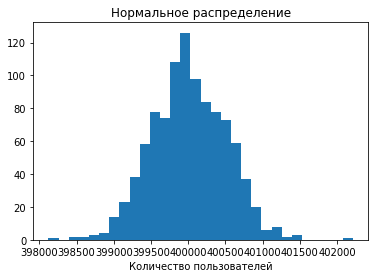

In [ ]:
s = np.random.normal(mu, sigma, 1000)

plt.hist(s, 30)
plt.title('Нормальное распределение')
plt.xlabel('Количество пользователей');

***Вывод***

Вероятность того, что из 1 млн уведомлений откроют менее 399.5 тыс составляет 15.37 %.

### Общий вывод

Для исследования были получены данные от популярного сервиса аренды самокатов GoFast.

**На этапе предобработки были выполнены следующие действия:**

1. Изменены типы данных в некоторых столбцах на более подходящие.
2. Добавлены новые столбцы для использования их в будущем исследовании.
3. Изучены данные на предмет дубликатов и по-возможности произведено их исправление.
4. Изучены данные на предмет аномалий. Часть аномалий было исключено из некотрых исследований.
5. Обнаружен слишком малый (12, 13 лет) возраст арендаторов.
6. Замечено, что 37,3% поездок являются повторными, то есть совершаются одними и теми же пользователями в течении месяца.
7. Самые популярные имена пользователей - Мария и Анна среди пользователей женского пола, Александр и Дмитрий - среди мужчин.

**На этапе исследовательского анализа данных мы установили, что:**

1. Наиболее популярен сервис в Пятигорске, наименее - в Москве.
2. 54.4% пользователей не используют подписку, причем перевес таких пользователей хорошен выражен везде, кроме Москвы (где доли пользователей двух типов равны) и Омска (где перевес есть, но не столь заметный).
3. Минимальный возраст пользователя составил 12 лет, максимальный - 43. "Нормальным" возрастом пользователя может счиаться от 13 до 37, но большинство пользователей - люди возрастом 22-28 лет. Средний практически совпадает с медианным, и они составляют 25 лет. Распределение по возрастам среди пользователей с подпиской и без схожи между собой (с учетом количеств) и стремяться к нормальному.
4. Максимальное расстояние, на которое брали самокат в аренду, составило 7.2 км, минимальное - меньше метра (что может быть ошибкой при сборе данных).
5. Распределение расстояния за одну поездку в целом похоже на нормальное, однако имеет второй пик в начале. Нормальными можно считать поездки от 800 метров до 5.6 км, а основная масса пользователей совершают поездки от 2.5 до 3.8 км.
6. Среднее и медиана отличаются мало и составляют приблизительно 18 минут. Нормальными можно считать поездки от 3 до 34 минут, но основное большинство пользователей тратит на одну поездку 3.67 до 21.75 минут.
7. Уточнены ранее видлимые аномалии - трата всего половины минуты на преодоление расстояний от 4 до 7.2 км.
8. Явных изменений сезонной активности обнаружно не было.
9. Совокупный портрет среднестатистического пользователя: девушка по имени Анна или Мария, либо парень с именем Дмитрий или Александр, возрастом 25 лет из Пятигорска, предпочитающий пользоваться сервисом без подписки и совершающий поездки около трех километров за раз, тратящий на нее 18 минут.


**На этапе объединения данных были выполнены следующие действия и установлено что:**

1. Объединены три исходных датасета в один.
2. Созданы на его основе два новых - для пользователей с подпиской и без.
3. Аномалии времени (полминуты для расстояния более 4 км) оказались характерны только для пользователей без подписки.
4. Распределение времени поездок у двух групп пользователей (с подпиской и без) похоже (и схоже с тем, что мы видели ранее, без деления на группы), за исключением аномалий в полминуты у неподписчиков. Самые быстрые по времени из поездок (даже без учета указанных аномалий) были совершены пользователями без подписки, а самые продолжительные - пользователями с подпиской.
5. Гистограммы распределения  расстояния для обеих групп пользователей также выглядят похоже, и даже обе имеют второй пик в начале. Но вторая гистограмма (для неподписчиков) заметно шире первой (с подписчиками).

**На этапе подсчета выручки были выполнены следующие действия, а также установлено что:**

1. Созданы два агрегированных датафрейма.
2. Распределение значений выручки с пользователя в месяц шире у неподписчиков, чем у подписчиков. Диапазон значений выручки за месяц у подписчиков уже, но минимальная стандартная трата заметно выше, чем у неподписчиков. При этом стандартный максимум подписчиков также ниже, чем у неподписчиков, но ненамного.
3. Обычными тратами для подписчиков можно считать от 223 до 580 рублей в месяц (для неподписчиков от 58 до 800), но основная часть подписчиков приносит от 301 до 409 рублей в месяц (неподписчики от 194 до 428). При этом наименьшая выручка с пользователя в месяц составила 223 рубля для подписчика (58 рубля для неподписчика), а самая высокая - 955 рублей (1444 рублей соответственно).

**На этапе проверки гипотез мы проверили несколько гипотез и установили:**

1. Можно утверждать, что пользователи с подпиской тратят больше времени на поездки.
2. Можно утверждать, что пользователи с подпиской за одну поездку проезжают 3130 метров или менее.
3. Можно утверждать, что пользователи с подпиской тратят в сервисе больше денег.
4. Для изучения гипотезы о снижении количеств обращений после обновления серверов нам бы понадобился метод scipy.stats.ttest_rel() с параметром alternative='greater'.

**На этапе задач по распределению:**

1. Чтобы как минимум 100 текущих клиентов продлили подписку с вероятностью близкой к 95% необходимо раздать 1172 промокода.

2. Выяснили, что вероятность того, что из 1 млн уведомлений откроют менее 399.5 тыс составляет 15.37 %.

**Рекомендации по улучшению сбора данных:**

1. Выявить и устранить причины появления пользователей до 18 лет (или иного возраста, допускающего управление самокатом в целом и сервисом заказчика в частности).

2. Выявить причины появления аномально коротких по времени поездок на большие расстояния.

3. Выявить причины появления иных аномалий, в том числе нарушающих репрезентативность выборки.

Например, схожие расстояния в некоторых случаях требовали достаточно сильно различающегося времени на свое преодоление у одних и тех же пользователей.

4. С учетом появления в выборке пользователей подозрительно малого возраста проверить, нет ли иных нарушений правил пользования сервисов заказчика. Возможно, некоторые пользователи склонны превышать установленную законодательством или правилами договора аренды скорость, или использовать для перевозки более одного человека за раз.